# 🎓 Storytelling with Data: นักศึกษามหาวิทยาลัยไทย ปี 2567–2568

> **เป้าหมาย:** เรียนรู้กระบวนการ Data Storytelling ตั้งแต่ต้นจนจบ ตั้งแต่การโหลดข้อมูล → EDA → ทำความสะอาด → หา Insight → เตรียม Dashboard

---
Link Colab: https://colab.research.google.com/drive/12iS8AmW9iDkOhaVkUY2y7FP7KPjQHR_f

Link Dataset: https://www.thackle.or.th/th/dataset/82

| ขั้นตอน | หัวข้อ |
|--------|--------|
| 1️⃣ | Setup & Load Data |
| 2️⃣ | First Look (EDA เบื้องต้น) |
| 3️⃣ | Data Quality & Cleaning |
| 4️⃣ | Province Mapping (เติมจังหวัดที่ขาด) |
| 5️⃣ | Advanced EDA & Insights |
| 6️⃣ | Dashboard Preparation |

---
📦 **ข้อมูล:** จำนวนนักศึกษามหาวิทยาลัยทั่วประเทศไทย ภาคต้น ปีการศึกษา 2567 และ 2568  
🗂️ **แหล่งที่มา:**
องค์กร : สำนักงานปลัดกระทรวงการอุดมศึกษา วิทยาศาสตร์ วิจัยและนวัตกรรม
https://data.go.th/dataset/univ_std_11_011

🤔 ก่อนเริ่ม: **Data Storytelling** คืออะไร และทำไมถึงสำคัญ?

การวิเคราะห์ข้อมูลมิได้จำกัดอยู่เพียงการเขียนโค้ดและสร้างภาพข้อมูล หากแต่ครอบคลุมถึงการแปลความหมายเชิงลึก เพื่อเชื่อมโยงตัวเลขกับบริบทที่ผู้รับสารเข้าใจได้ และนำไปสู่การตัดสินใจได้อย่างมีประสิทธิผล


```
Raw Data → Analysis → Insight → Story → Decision
    ↑                                        ↑
  หลายคนทำได้               แต่น้อยคนทำถึงตรงนี้
```


**Data Storytelling** ที่ดีต้องมี 3 องค์ประกอบ:

📊 Data — ตัวเลขที่ถูกต้อง เชื่อถือได้

🎨 Visualization — กราฟที่สื่อความหมายได้ชัดเจน

📖 Narrative — เรื่องราวที่เชื่อมทุกอย่างเข้าด้วยกัน

## 1️⃣ Setup & Load Data

### 📦 ติดตั้งและ Import Libraries

ก่อนเริ่มต้น เราต้อง import library ที่จำเป็นสำหรับการวิเคราะห์ข้อมูลและสร้างกราฟ โดย `pandas` ใช้สำหรับจัดการตาราง, `numpy` สำหรับคำนวณเชิงตัวเลข, `matplotlib` และ `seaborn` สำหรับสร้าง static chart, `plotly` สำหรับ interactive visualization และ `warnings` เพื่อซ่อน warning ที่ไม่จำเป็น การเตรียม environment ที่ดีตั้งแต่ต้นจะช่วยให้ workflow ราบรื่นตลอดทั้ง notebook

In [ ]:
# ติดตั้ง library เพิ่มเติม (ถ้าจำเป็น)
!pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
#เพิ่มฟอนต์เข้าไปในระบบ
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120

print('✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูลแล้ว 🚀')

✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูลแล้ว 🚀


### 📂 โหลดข้อมูล

เราโหลดไฟล์ CSV สองปีพร้อมกัน โดยใช้ `encoding='utf-8-sig'` เพื่อรองรับอักขระภาษาไทยและ BOM (Byte Order Mark) ที่มักปรากฏในไฟล์ที่ export จากระบบราชการไทย หลังจากโหลดแล้ว เราทำการตรวจสอบขนาดข้อมูล (shape) และแสดงตัวอย่างแถว (head) เพื่อให้เข้าใจโครงสร้างของ dataset ก่อนลงมือวิเคราะห์ การ print ชื่อคอลัมน์ช่วยให้เห็นความแตกต่างระหว่างสองปีได้ทันที

In [ ]:
# โหลดข้อมูล
# 📌 ถ้าใช้ Google Colab: ให้ upload ไฟล์ผ่าน Files panel หรือใช้ Google Drive
# from google.colab import files
# uploaded = files.upload()

df_67 = pd.read_csv('univ_std_11_01_2567.csv', encoding='utf-8-sig')
df_68 = pd.read_csv('univ_std_11_01_2568.csv', encoding='utf-8-sig')

print('=' * 60)
print('📅 ข้อมูลปีการศึกษา 2567')
print(f'   ➜ จำนวนแถว: {df_67.shape[0]:,} แถว | คอลัมน์: {df_67.shape[1]} คอลัมน์')
print(f'   ➜ คอลัมน์: {df_67.columns.tolist()}')
print()
print('📅 ข้อมูลปีการศึกษา 2568')
print(f'   ➜ จำนวนแถว: {df_68.shape[0]:,} แถว | คอลัมน์: {df_68.shape[1]} คอลัมน์')
print(f'   ➜ คอลัมน์: {df_68.columns.tolist()}')
print('=' * 60)

print()
print('🔍 ตัวอย่างข้อมูลปี 2567:')
display(df_67.head(3))
print('🔍 ตัวอย่างข้อมูลปี 2568:')
display(df_68.head(3))

📅 ข้อมูลปีการศึกษา 2567
   ➜ จำนวนแถว: 21,893 แถว | คอลัมน์: 10 คอลัมน์
   ➜ คอลัมน์: ['ACADEMIC_YEAR', 'SEMESTER', 'UNIV_TYPE_NAME', 'UNIV_MASTERNAME_TH', 'UNIV_NAME_TH', 'FAC_NAME', 'PROGRAM_NAME', 'LEV_NAME_ENG', 'GENDER_NAME', 'ALL STD']

📅 ข้อมูลปีการศึกษา 2568
   ➜ จำนวนแถว: 22,062 แถว | คอลัมน์: 11 คอลัมน์
   ➜ คอลัมน์: ['ACADEMIC_YEAR', 'SEMESTER', 'UNIV_PROVINCE_NAME', 'UNIV_TYPE_NAME', 'UNIV_MASTERNAME_TH', 'UNIV_NAME_TH', 'FAC_NAME', 'PROGRAM_NAME', 'LEV_NAME_TH', 'GENDER_NAME', 'ALL STD']

🔍 ตัวอย่างข้อมูลปี 2567:


,ACADEMIC_YEAR,SEMESTER,UNIV_TYPE_NAME,UNIV_MASTERNAME_TH,UNIV_NAME_TH,FAC_NAME,PROGRAM_NAME,LEV_NAME_ENG,GENDER_NAME,ALL STD
0,2567.0,1.0,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลกรุงเทพ,มหาวิทยาลัยเทคโนโลยีราชมงคลกรุงเทพ,คณะเทคโนโลยีคหกรรมศาสตร์,เทคโนโลยีเสื้อผ้า,ป.ตรี,ชาย,15.0
1,2567.0,1.0,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลกรุงเทพ,มหาวิทยาลัยเทคโนโลยีราชมงคลกรุงเทพ,คณะเทคโนโลยีคหกรรมศาสตร์,เทคโนโลยีเสื้อผ้า,ป.ตรี,หญิง,33.0
2,2567.0,1.0,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลกรุงเทพ,มหาวิทยาลัยเทคโนโลยีราชมงคลกรุงเทพ,คณะเทคโนโลยีคหกรรมศาสตร์,การพัฒนาผลิตภัณฑ์อาหาร,ป.ตรี,ชาย,8.0


🔍 ตัวอย่างข้อมูลปี 2568:


,ACADEMIC_YEAR,SEMESTER,UNIV_PROVINCE_NAME,UNIV_TYPE_NAME,UNIV_MASTERNAME_TH,UNIV_NAME_TH,FAC_NAME,PROGRAM_NAME,LEV_NAME_TH,GENDER_NAME,ALL STD
0,2568.0,1.0,เชียงใหม่,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลล้านนา,มหาวิทยาลัยเทคโนโลยีราชมงคลล้านนา วิทยาเขตภาค...,คณะบริหารธุรกิจและศิลปศาสตร์,การจัดการ,ป.ตรี,ชาย,449.0
1,2568.0,1.0,เชียงใหม่,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลล้านนา,มหาวิทยาลัยเทคโนโลยีราชมงคลล้านนา วิทยาเขตภาค...,คณะบริหารธุรกิจและศิลปศาสตร์,การตลาด,ป.ตรี,หญิง,5.0
2,2568.0,1.0,เชียงใหม่,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลล้านนา,มหาวิทยาลัยเทคโนโลยีราชมงคลล้านนา วิทยาเขตภาค...,คณะบริหารธุรกิจและศิลปศาสตร์,การท่องเที่ยวและการบริการ,ป.ตรี,ชาย,84.0


### 🔎 สังเกตความแตกต่างของ Schema

จากการโหลดข้อมูล เราพบความแตกต่างสำคัญ 2 อย่างระหว่างข้อมูลสองปี ได้แก่ (1) ปี 2567 **ไม่มีคอลัมน์ `UNIV_PROVINCE_NAME`** ซึ่งเป็นข้อมูลจังหวัดที่ตั้งของมหาวิทยาลัย และ (2) คอลัมน์ระดับการศึกษามีชื่อต่างกัน — ปี 2567 ใช้ `LEV_NAME_ENG` ส่วนปี 2568 ใช้ `LEV_NAME_TH` ความแตกต่างนี้จะต้องได้รับการแก้ไขก่อนนำข้อมูลมา merge กัน

In [ ]:
# เปรียบเทียบ Schema
cols_67 = set(df_67.columns)
cols_68 = set(df_68.columns)

print('📌 คอลัมน์ที่มีใน 2568 แต่ไม่มีใน 2567:')
for c in cols_68 - cols_67:
    print(f'   ❗ {c}')

print()
print('📌 คอลัมน์ที่มีใน 2567 แต่ไม่มีใน 2568:')
for c in cols_67 - cols_68:
    print(f'   ❗ {c}')

print()
print('💡 ข้อสรุป: ปี 2567 ขาดคอลัมน์ UNIV_PROVINCE_NAME → ต้องทำ Province Mapping')

📌 คอลัมน์ที่มีใน 2568 แต่ไม่มีใน 2567:
   ❗ LEV_NAME_TH
   ❗ UNIV_PROVINCE_NAME

📌 คอลัมน์ที่มีใน 2567 แต่ไม่มีใน 2568:
   ❗ LEV_NAME_ENG

💡 ข้อสรุป: ปี 2567 ขาดคอลัมน์ UNIV_PROVINCE_NAME → ต้องทำ Province Mapping


---
## 2️⃣ First Look — EDA เบื้องต้น

### 📊 ภาพรวมสถิติเบื้องต้น

ขั้นตอน Exploratory Data Analysis (EDA) เบื้องต้น คือการสำรวจข้อมูลอย่างรวดเร็วเพื่อให้เข้าใจ "รูปร่าง" ของ dataset ก่อนลงลึก เราดูสถิติพื้นฐาน (`describe()`), จำนวนค่า null, ค่า unique ในแต่ละคอลัมน์ และยอดนักศึกษารวม ข้อมูลเหล่านี้ช่วยให้ตั้งสมมติฐานได้ว่าข้อมูลมีปัญหาอะไร และควรโฟกัสวิเคราะห์ตรงไหน

In [ ]:
# สถิติเบื้องต้น
for year, df in [('2567', df_67), ('2568', df_68)]:
    total = int(df['ALL STD'].sum())
    null_count = df.isnull().sum().sum()
    univ_count = df['UNIV_MASTERNAME_TH'].nunique()
    fac_count = df['FAC_NAME'].nunique()
    prog_count = df['PROGRAM_NAME'].nunique()

    print(f'🎓 ปีการศึกษา {year}')
    print(f'   👥 นักศึกษารวม  : {total:>12,} คน')
    print(f'   🏛️ มหาวิทยาลัย  : {univ_count:>12,} แห่ง')
    print(f'   🏫 คณะ        : {fac_count:>12,} คณะ')
    print(f'   📚 หลักสูตร     : {prog_count:>12,} หลักสูตร')
    print(f'   ⚠️ ค่า Null     : {null_count:>12,} ค่า')
    print()

🎓 ปีการศึกษา 2567
   👥 นักศึกษารวม  :    1,899,470 คน
   🏛️ มหาวิทยาลัย  :          159 แห่ง
   🏫 คณะ        :          518 คณะ
   📚 หลักสูตร     :        2,843 หลักสูตร
   ⚠️ ค่า Null     :           44 ค่า

🎓 ปีการศึกษา 2568
   👥 นักศึกษารวม  :    2,000,559 คน
   🏛️ มหาวิทยาลัย  :          165 แห่ง
   🏫 คณะ        :          522 คณะ
   📚 หลักสูตร     :        3,073 หลักสูตร
   ⚠️ ค่า Null     :           24 ค่า



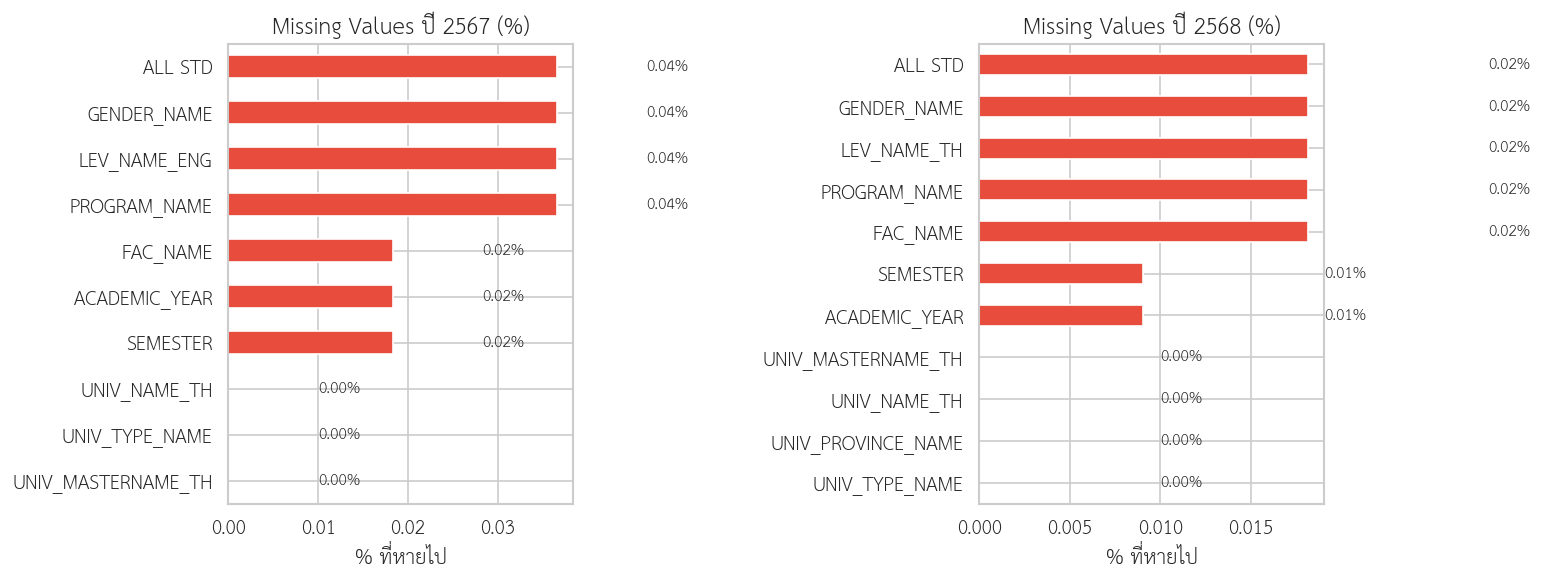

💡 แดง = มีค่า null


In [ ]:
# ดู Missing Values แบบ Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (year, df) in zip(axes, [('2567', df_67), ('2568', df_68)]):
    null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in null_pct]
    null_pct.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Missing Values ปี {year} (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('% ที่หายไป')
    for i, v in enumerate(null_pct):
        ax.text(v + 0.01, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('💡 แดง = มีค่า null' )

---
## 3️⃣ Data Quality & Cleaning 🧹

### ตรวจสอบข้อมูลผิดปกติ

ก่อนวิเคราะห์จริง เราต้องทำความสะอาดข้อมูลก่อน ขั้นตอนนี้ครอบคลุมการ

(1) ลบแถว null ที่ไม่มีข้อมูลสำคัญ

(2) ตรวจสอบว่า `UNIV_TYPE_NAME` มี garbage data ที่หลุดมาจากแถวอื่นหรือไม่

(3) ทำให้ชื่อคอลัมน์ระดับการศึกษาตรงกัน และ

(4) rename คอลัมน์ให้สอดคล้องกัน

Data Cleaning ที่ดีจะทำให้ผลการวิเคราะห์ถูกต้องและน่าเชื่อถือ

In [ ]:
# ตรวจสอบ UNIV_TYPE_NAME ว่ามี garbage หรือไม่
print('🏷️ ประเภทมหาวิทยาลัยในปี 2567:')
print(df_67['UNIV_TYPE_NAME'].value_counts())

print()
print('🏷️ ประเภทมหาวิทยาลัยในปี 2568:')
print(df_68['UNIV_TYPE_NAME'].value_counts())

🏷️ ประเภทมหาวิทยาลัยในปี 2567:
UNIV_TYPE_NAME
มหาวิทยาลัยรัฐในกำกับ          9250
มหาวิทยาลัยราชภัฎ              4763
มหาวิทยาลัยเอกชน               2640
มหาวิทยาลัยเทคโนโลยีราชมงคล    2045
มหาวิทยาลัยรัฐจำกัดรับ         1435
สถานศึกษานอกสังกัดฯ             442
วิทยาลัยเอกชน                   383
มหาวิทยาลัยรัฐไม่จำกัดรับ       377
สถาบันวิทยาลัยชุมชน             300
สถาบันเอกชน                     254
แพทยศาสตร์                        2
วิศวกรรมโยธา - ชลประทาน           2
Name: count, dtype: int64

🏷️ ประเภทมหาวิทยาลัยในปี 2568:
UNIV_TYPE_NAME
มหาวิทยาลัยรัฐในกำกับ          8542
มหาวิทยาลัยราชภัฎ              5241
มหาวิทยาลัยเอกชน               2951
มหาวิทยาลัยเทคโนโลยีราชมงคล    2109
มหาวิทยาลัยรัฐจำกัดรับ         1524
มหาวิทยาลัยรัฐไม่จำกัดรับ       394
วิทยาลัยเอกชน                   392
สถานศึกษานอกสังกัดฯ             324
สถาบันวิทยาลัยชุมชน             297
สถาบันเอกชน                     286
ป.ตรี                             2
Name: count, dtype: int64


In [ ]:
# กำหนด valid UNIV_TYPE
VALID_TYPES = [
    'มหาวิทยาลัยเทคโนโลยีราชมงคล',
    'มหาวิทยาลัยเอกชน',
    'มหาวิทยาลัยรัฐในกำกับ',
    'มหาวิทยาลัยราชภัฎ',
    'สถานศึกษานอกสังกัดฯ',
    'วิทยาลัยเอกชน',
    'สถาบันวิทยาลัยชุมชน',
    'มหาวิทยาลัยรัฐไม่จำกัดรับ',
    'มหาวิทยาลัยรัฐจำกัดรับ',
    'สถาบันเอกชน'
]

print(f'🗑️ ก่อน clean — ปี 2567: {len(df_67):,} แถว | ปี 2568: {len(df_68):,} แถว')

# ลบแถว null ที่สำคัญ และ garbage rows
df_67c = df_67.dropna(subset=['ALL STD', 'UNIV_MASTERNAME_TH', 'GENDER_NAME']).copy()
df_68c = df_68.dropna(subset=['ALL STD', 'UNIV_MASTERNAME_TH', 'GENDER_NAME']).copy()

df_67c = df_67c[df_67c['UNIV_TYPE_NAME'].isin(VALID_TYPES)].copy()
df_68c = df_68c[df_68c['UNIV_TYPE_NAME'].isin(VALID_TYPES)].copy()

# Rename LEV column ให้ตรงกัน
df_67c = df_67c.rename(columns={'LEV_NAME_ENG': 'LEV_NAME_TH'})

# แปลง ALL STD เป็น int
df_67c['ALL STD'] = df_67c['ALL STD'].astype(int)
df_68c['ALL STD'] = df_68c['ALL STD'].astype(int)

print(f'✅ หลัง clean  — ปี 2567: {len(df_67c):,} แถว | ปี 2568: {len(df_68c):,} แถว')
print(f'🗑️ ลบออก      — ปี 2567: {len(df_67)-len(df_67c):,} แถว | ปี 2568: {len(df_68)-len(df_68c):,} แถว')

🗑️ ก่อน clean — ปี 2567: 21,893 แถว | ปี 2568: 22,062 แถว
✅ หลัง clean  — ปี 2567: 21,885 แถว | ปี 2568: 22,058 แถว
🗑️ ลบออก      — ปี 2567: 8 แถว | ปี 2568: 4 แถว


---
## 4️⃣ Province Mapping — เติมจังหวัดที่ขาดใน ปี 2567 🗺️

### 💡 ทำไมต้องทำ Province Mapping?

ข้อมูลปี 2567 ไม่มีคอลัมน์จังหวัด ทำให้ไม่สามารถวิเคราะห์ตามภูมิภาคหรือจังหวัดได้ กลยุทธ์ที่ใช้คือ **สร้าง mapping dictionary** จากข้อมูลปี 2568 ซึ่งมีข้อมูลจังหวัดครบถ้วน โดย map ผ่านชื่อมหาวิทยาลัย (`UNIV_MASTERNAME_TH`) เพราะเป็น key ที่ unique กว่า `UNIV_NAME_TH` (ซึ่งบางมหาวิทยาลัยมีหลายวิทยาเขต) แล้วใช้ `map()` เพื่อเติมค่าจังหวัดใน dataframe ปี 2567 สำหรับมหาวิทยาลัยที่ไม่พบใน mapping จะใช้ฐานข้อมูลเสริมที่สร้างด้วยตนเอง

In [ ]:
# สร้าง mapping จากปี 2568: UNIV_MASTERNAME_TH -> UNIV_PROVINCE_NAME
# ใช้ mode (ค่าที่พบมากที่สุด) เพื่อแก้ปัญหามหาวิทยาลัยที่มีหลายจังหวัด (เช่น มรภ.)
province_map = (
    df_68c.groupby('UNIV_MASTERNAME_TH')['UNIV_PROVINCE_NAME']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

print(f'🗺️ สร้าง mapping สำเร็จ: {len(province_map)} มหาวิทยาลัย')

# ตัวอย่าง mapping
sample_keys = list(province_map.items())[:8]
print()
print('📋 ตัวอย่าง mapping:')
for k, v in sample_keys:
    print(f'   {k[:40]:<40} → {v}')

🗺️ สร้าง mapping สำเร็จ: 162 มหาวิทยาลัย

📋 ตัวอย่าง mapping:
   จุฬาลงกรณ์มหาวิทยาลัย                    → กรุงเทพมหานคร
   มหาวิทยาลัยกรุงเทพ                       → ปทุมธานี
   มหาวิทยาลัยกรุงเทพธนบุรี                 → กรุงเทพมหานคร
   มหาวิทยาลัยกรุงเทพสุวรรณภูมิ             → กรุงเทพมหานคร
   มหาวิทยาลัยการกีฬาแห่งชาติ               → เชียงใหม่
   มหาวิทยาลัยการจัดการและเทคโนโลยีอีสเทิร์ → อุบลราชธานี
   มหาวิทยาลัยกาฬสินธุ์                     → กาฬสินธุ์
   มหาวิทยาลัยขอนแก่น                       → ขอนแก่น


In [ ]:
# เติม province ให้ปี 2567
df_67c['UNIV_PROVINCE_NAME'] = df_67c['UNIV_MASTERNAME_TH'].map(province_map)

# ตรวจสอบว่ามีมหาวิทยาลัยที่ map ไม่ได้
not_mapped = df_67c[df_67c['UNIV_PROVINCE_NAME'].isnull()]['UNIV_MASTERNAME_TH'].unique()

print(f'⚠️ มหาวิทยาลัยที่ยังไม่มีจังหวัด: {len(not_mapped)} แห่ง')
for u in not_mapped:
    print(f'   ❓ {u}')

⚠️ มหาวิทยาลัยที่ยังไม่มีจังหวัด: 5 แห่ง
   ❓ มหาวิทยาลัยมหาจุฬาลงกรณราชวิทยาลัย
   ❓ มหาวิทยาลัยมหามกุฏราชวิทยาลัย
   ❓ วิทยาลัยเซาธ์อีสท์บางกอก
   ❓ วิทยาลัยนานาชาติเซนต์เทเรซา
   ❓ โรงเรียนนายเรืออากาศนวมินทกษัตริยาธิราช


In [ ]:
# เติมข้อมูลจังหวัดด้วยมือสำหรับมหาวิทยาลัยที่ไม่มีใน mapping
# (มหาวิทยาลัยที่มีใน 67 แต่ไม่มีใน 68 หรือชื่อต่างกันเล็กน้อย)
manual_map = {
    'มหาวิทยาลัยมหามกุฏราชวิทยาลัย'                      : 'นครปฐม',
    'มหาวิทยาลัยมหาจุฬาลงกรณราชวิทยาลัย'                : 'พระนครศรีอยุธยา',
    'วิทยาลัยเซาธ์อีสท์บางกอก'                           : 'กรุงเทพมหานคร',
    'วิทยาลัยนานาชาติเซนต์เทเรซา'                        : 'นครนายก',
    'โรงเรียนนายเรืออากาศนวมินทกษัตริยาธิราช'            : 'กรุงเทพมหานคร',
}

for univ, prov in manual_map.items():
    df_67c.loc[df_67c['UNIV_MASTERNAME_TH'] == univ, 'UNIV_PROVINCE_NAME'] = prov
# — กรองเฉพาะจังหวัดจริง ──
THAI_PROVINCES = [
    'กรุงเทพมหานคร','กระบี่','กาญจนบุรี','กาฬสินธุ์','กำแพงเพชร','ขอนแก่น',
    'จันทบุรี','ฉะเชิงเทรา','ชลบุรี','ชัยนาท','ชัยภูมิ','ชุมพร','เชียงราย',
    'เชียงใหม่','ตรัง','ตราด','ตาก','นครนายก','นครปฐม','นครพนม','นครราชสีมา',
    'นครศรีธรรมราช','นครสวรรค์','นนทบุรี','นราธิวาส','น่าน','บึงกาฬ','บุรีรัมย์',
    'ปทุมธานี','ประจวบคีรีขันธ์','ปราจีนบุรี','ปัตตานี','พระนครศรีอยุธยา','พะเยา',
    'พัทลุง','พิจิตร','พิษณุโลก','เพชรบุรี','เพชรบูรณ์','แพร่','ภูเก็ต',
    'มหาสารคาม','มุกดาหาร','แม่ฮ่องสอน','ยโสธร','ยะลา','ร้อยเอ็ด','ระนอง',
    'ระยอง','ราชบุรี','ลพบุรี','ลำปาง','ลำพูน','เลย','ศรีสะเกษ','สกลนคร',
    'สงขลา','สตูล','สมุทรปราการ','สมุทรสงคราม','สมุทรสาคร','สระแก้ว','สระบุรี',
    'สิงห์บุรี','สุโขทัย','สุพรรณบุรี','สุราษฎร์ธานี','สุรินทร์','หนองคาย',
    'หนองบัวลำภู','อ่างทอง','อำนาจเจริญ','อุดรธานี','อุตรดิตถ์','อุทัยธานี','อุบลราชธานี'
]

df_67c = df_67c[df_67c['UNIV_PROVINCE_NAME'].isin(THAI_PROVINCES)]
df_67c = df_67c[df_67c['UNIV_PROVINCE_NAME'].isin(THAI_PROVINCES)]


remaining_null = df_67c['UNIV_PROVINCE_NAME'].isnull().sum()
filled = len(df_67c) - remaining_null

print('✅ Province Mapping สำเร็จ!')
print(f'   📍 แถวที่มีจังหวัดแล้ว : {filled:,} / {len(df_67c):,}')
print(f'   ⚠️  ยังขาดจังหวัด     : {remaining_null:,} แถว')

✅ Province Mapping สำเร็จ!
   📍 แถวที่มีจังหวัดแล้ว : 21,885 / 21,885
   ⚠️  ยังขาดจังหวัด     : 0 แถว


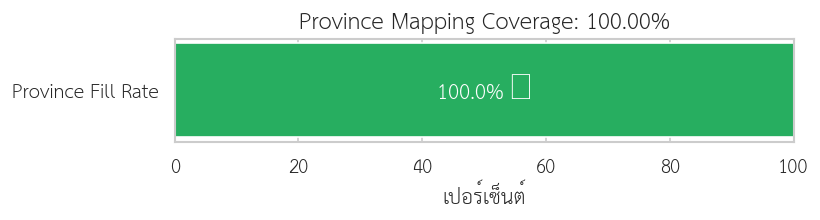

In [ ]:
# สรุปผล mapping
fill_rate = df_67c['UNIV_PROVINCE_NAME'].notna().mean() * 100

fig, ax = plt.subplots(figsize=(7, 2))
ax.barh(['Province Fill Rate'], [fill_rate], color='#27ae60', height=0.4)
ax.barh(['Province Fill Rate'], [100 - fill_rate], left=[fill_rate], color='#e74c3c', height=0.4)
ax.set_xlim(0, 100)
ax.set_xlabel('เปอร์เซ็นต์')
ax.set_title(f'Province Mapping Coverage: {fill_rate:.2f}%', fontsize=13, fontweight='bold')
ax.text(fill_rate / 2, 0, f'{fill_rate:.1f}% ✅', ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

### 🔗 รวมข้อมูลสองปีเป็น DataFrame เดียว

เมื่อข้อมูลสะอาดและครบถ้วนแล้ว เราทำการ **concat** ทั้งสองปีเข้าด้วยกัน โดยเลือกเฉพาะคอลัมน์ที่ตรงกัน การรวมข้อมูลนี้จะทำให้สามารถเปรียบเทียบข้ามปีได้ง่าย และทำให้ทุก visualization สามารถกรองตามปีได้ทันที ซึ่งเป็นรูปแบบ **"Tidy Data"** ที่ดีที่สุดสำหรับการวิเคราะห์

In [ ]:
# เลือกคอลัมน์ที่ใช้ร่วมกัน
COMMON_COLS = [
    'ACADEMIC_YEAR', 'SEMESTER', 'UNIV_PROVINCE_NAME', 'UNIV_TYPE_NAME',
    'UNIV_MASTERNAME_TH', 'UNIV_NAME_TH', 'FAC_NAME', 'PROGRAM_NAME',
    'LEV_NAME_TH', 'GENDER_NAME', 'ALL STD'
]

df_all = pd.concat([df_67c[COMMON_COLS], df_68c[COMMON_COLS]], ignore_index=True)
df_all['ACADEMIC_YEAR'] = df_all['ACADEMIC_YEAR'].astype(int)

print(f'✅ รวมข้อมูลสำเร็จ! ได้ DataFrame ขนาด {df_all.shape[0]:,} แถว x {df_all.shape[1]} คอลัมน์')
display(df_all.sample(5))

✅ รวมข้อมูลสำเร็จ! ได้ DataFrame ขนาด 43,943 แถว x 11 คอลัมน์


,ACADEMIC_YEAR,SEMESTER,UNIV_PROVINCE_NAME,UNIV_TYPE_NAME,UNIV_MASTERNAME_TH,UNIV_NAME_TH,FAC_NAME,PROGRAM_NAME,LEV_NAME_TH,GENDER_NAME,ALL STD
6794,2567,1.0,เชียงใหม่,มหาวิทยาลัยรัฐในกำกับ,มหาวิทยาลัยเชียงใหม่,มหาวิทยาลัยเชียงใหม่,คณะวิศวกรรมศาสตร์,วิศวกรรมหุ่นยนต์และปัญญาประดิษฐ์,ป.ตรี,ชาย,114
16873,2567,1.0,กรุงเทพมหานคร,มหาวิทยาลัยราชภัฎ,มหาวิทยาลัยราชภัฏธนบุรี,มหาวิทยาลัยราชภัฏธนบุรี,คณะมนุษยศาสตร์และสังคมศาสตร์,นาฏศิลป์และการแสดง,ป.ตรี,ชาย,1
37580,2568,1.0,ปทุมธานี,มหาวิทยาลัยรัฐในกำกับ,มหาวิทยาลัยธรรมศาสตร์,มหาวิทยาลัยธรรมศาสตร์ ศูนยรังสิต,คณะทันตแพทยศาสตร์,ทันตแพทยศาสตร์,ป.ตรี,หญิง,258
42757,2568,1.0,สุราษฎร์ธานี,มหาวิทยาลัยรัฐในกำกับ,มหาวิทยาลัยสงขลานครินทร์,มหาวิทยาลัยสงขลานครินทร์ วิทยาเขตสุราษฎร์ธานี,คณะวิทยาศาสตร์และเทคโนโลยีอุตสาหกรรม,อาชีวอนามัยและความปลอดภัย,ป.ตรี,หญิง,443
24531,2568,1.0,กรุงเทพมหานคร,มหาวิทยาลัยเทคโนโลยีราชมงคล,มหาวิทยาลัยเทคโนโลยีราชมงคลรัตนโกสินทร์,มหาวิทยาลัยเทคโนโลยีราชมงคลรัตนโกสินทร์ วิทยา...,คณะศิลปศาสตร์,ภาษาญี่ปุ่น,ป.ตรี,หญิง,61


---
## 5️⃣ Advanced EDA & Insights 🔬

### 5.1 📈 ภาพรวม: จำนวนนักศึกษาเพิ่มหรือลดอย่างไร?

การวิเคราะห์แนวโน้ม (Trend Analysis) ถือเป็นขั้นตอนเบื้องต้นที่สำคัญที่สุดก่อนการวิเคราะห์เชิงลึกในทุกมิติ เนื่องจากตัวเลขภาพรวมทำหน้าที่เป็นบริบทอ้างอิง (Baseline Context) ที่ช่วยให้การตีความข้อมูลในระดับย่อยมีความถูกต้องและแม่นยำมากยิ่งขึ้น

การวิเคราะห์ในขั้นตอนนี้ครอบคลุม 2 ระดับ ได้แก่

ระดับที่ 1 — ภาพรวมระดับประเทศ (Nationwide) เพื่อทราบทิศทางโดยรวมของระบบอุดมศึกษาว่ามีการขยายตัวหรือหดตัว และในอัตราเท่าใด

ระดับที่ 2 — แยกตามประเภทสถาบัน (Institutional Type) เพื่อตรวจสอบว่าการเปลี่ยนแปลงที่เกิดขึ้นเป็นแบบ Uniform Growth คือทุกประเภทสถาบันเติบโตในทิศทางเดียวกัน หรือเป็นแบบ Selective Growth คือมีเพียงบางประเภทที่ได้รับประโยชน์ ซึ่งหากเป็นกรณีหลัง ย่อมบ่งชี้ถึงการเปลี่ยนแปลงเชิงโครงสร้าง (Structural Shift) ในระบบการศึกษา

In [ ]:
# ภาพรวมรวม
total_by_year = df_all.groupby('ACADEMIC_YEAR')['ALL STD'].sum()
change = total_by_year[2568] - total_by_year[2567]
pct_change = change / total_by_year[2567] * 100

print('=' * 50)
print(f'📊 ปีการศึกษา 2567: {total_by_year[2567]:>12,} คน')
print(f'📊 ปีการศึกษา 2568: {total_by_year[2568]:>12,} คน')
print(f'📈 เพิ่ม/ลด        : {change:>+12,} คน')
print(f'📈 % เปลี่ยนแปลง  : {pct_change:>+12.2f}%')
print('=' * 50)

📊 ปีการศึกษา 2567:    1,899,470 คน
📊 ปีการศึกษา 2568:    2,000,559 คน
📈 เพิ่ม/ลด        :     +101,089 คน
📈 % เปลี่ยนแปลง  :        +5.32%


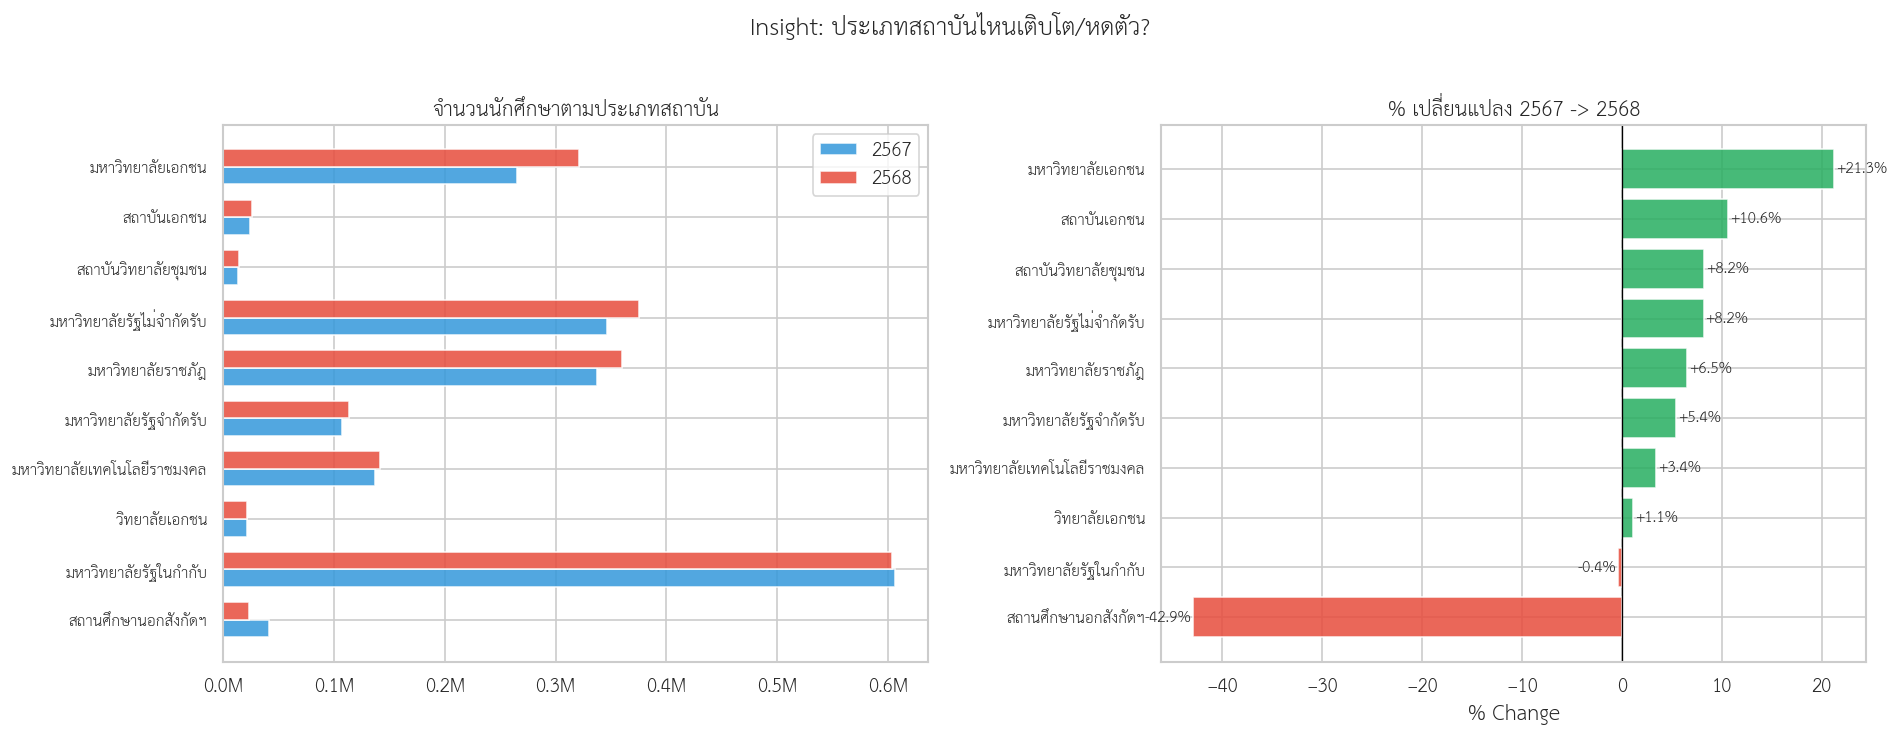

In [ ]:
# เปรียบเทียบแต่ละประเภทสถาบัน
by_type = df_all.groupby(['ACADEMIC_YEAR', 'UNIV_TYPE_NAME'])['ALL STD'].sum().unstack(0)
by_type['change_pct'] = (by_type[2568] - by_type[2567]) / by_type[2567] * 100
by_type = by_type.sort_values('change_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟแท่งเปรียบเทียบ
x = np.arange(len(by_type))
w = 0.35
axes[0].barh(x - w/2, by_type[2567], w, label='2567', color='#3498db', alpha=0.85)
axes[0].barh(x + w/2, by_type[2568], w, label='2568', color='#e74c3c', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(by_type.index, fontsize=9)
axes[0].set_title('จำนวนนักศึกษาตามประเภทสถาบัน', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# กราฟ % change
colors = ['#27ae60' if v >= 0 else '#e74c3c' for v in by_type['change_pct']]
axes[1].barh(x, by_type['change_pct'], color=colors, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(by_type.index, fontsize=9)
axes[1].set_title('% เปลี่ยนแปลง 2567 -> 2568', fontweight='bold')
axes[1].set_xlabel('% Change')
for i, v in enumerate(by_type['change_pct']):
    axes[1].text(v + (0.2 if v >= 0 else -0.2), i, f'{v:+.1f}%',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Insight: ประเภทสถาบันไหนเติบโต/หดตัว?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**การวิเคราะห์แนวโน้มจำนวนนักศึกษาระหว่างปีการศึกษา 2567–2568**

**1. ภาพรวมระดับประเทศ**

ระบบอุดมศึกษาไทยมีจำนวนนักศึกษาเพิ่มขึ้นจาก 1,899,470 คน ในปีการศึกษา 2567 เป็น 2,000,559 คน ในปีการศึกษา 2568 คิดเป็นการเพิ่มขึ้น 101,089 คน หรือร้อยละ 5.32 ซึ่งบ่งชี้ว่าระบบอุดมศึกษาโดยรวมยังคงขยายตัวได้ในเชิงปริมาณ
อย่างไรก็ตาม การพิจารณาเพียงตัวเลขรวมในระดับประเทศอาจนำไปสู่การตีความที่คลาดเคลื่อนได้ เนื่องจากการเติบโตดังกล่าวมิได้กระจายตัวอย่างสม่ำเสมอ (Non-uniform Growth) ในทุกประเภทสถาบัน

**2. การวิเคราะห์แยกตามประเภทสถาบัน**

เมื่อวิเคราะห์ในระดับประเภทสถาบัน พบว่าการเปลี่ยนแปลงมีลักษณะเป็น Selective Growth อย่างชัดเจน โดยสามารถจำแนกได้เป็น 3 กลุ่ม ดังนี้

กลุ่มที่ 1 — เติบโตสูงกว่าค่าเฉลี่ยระบบ
มหาวิทยาลัยเอกชนมีอัตราการเติบโตสูงที่สุดในระบบที่ +21.3% ซึ่งสูงกว่าค่าเฉลี่ยของระบบโดยรวมถึง 4 เท่า รองลงมาคือสถาบันเอกชน (+10.6%) และสถาบันวิทยาลัยชุมชนกับมหาวิทยาลัยรัฐไม่จำกัดรับ (+8.2% เท่ากัน) การเติบโตของกลุ่มสถาบันเอกชนในระดับนี้บ่งชี้ถึงการเปลี่ยนแปลงพฤติกรรมการเลือกศึกษาต่อของนักศึกษาที่มีนัยสำคัญ

กลุ่มที่ 2 — เติบโตต่ำกว่าค่าเฉลี่ยระบบ
มหาวิทยาลัยราชภัฏ (+6.5%) มหาวิทยาลัยรัฐจำกัดรับ (+5.4%) มหาวิทยาลัยเทคโนโลยีราชมงคล (+3.4%) และวิทยาลัยเอกชน (+1.1%) ยังคงมีจำนวนนักศึกษาเพิ่มขึ้น แต่ในอัตราที่ต่ำกว่าค่าเฉลี่ยของระบบ

กลุ่มที่ 3 — หดตัว
มหาวิทยาลัยรัฐในกำกับซึ่งประกอบด้วยสถาบันชั้นนำของประเทศ เช่น จุฬาลงกรณ์มหาวิทยาลัย มหาวิทยาลัยธรรมศาสตร์ และมหาวิทยาลัยมหิดล มีจำนวนนักศึกษาลดลงเล็กน้อยที่ -0.4% ซึ่งแม้จะเป็นตัวเลขที่ไม่สูงในเชิงสัมบูรณ์ แต่มีนัยสำคัญในแง่ที่เป็น กลุ่มเดียวในระบบที่มีแนวโน้มติดลบ สำหรับสถานศึกษานอกสังกัดฯ พบการหดตัวอย่างมีนัยสำคัญที่ -42.9% ซึ่งน่าจะเป็นผลมาจากการโอนย้ายสังกัดหรือการปิดตัวของสถาบันบางแห่ง มากกว่าการลดลงของความต้องการศึกษาต่อ


### 5.2 🗺️ Geographic Analysis — จังหวัดไหนมีนักศึกษามากที่สุด?

**การวิเคราะห์เชิงภูมิศาสตร์ (Geographic Analysis)**

มีวัตถุประสงค์เพื่อศึกษา รูปแบบการกระจายตัวเชิงพื้นที่ (Spatial Distribution Pattern) ของนักศึกษาในระบบอุดมศึกษาไทย โดยมุ่งตอบคำถามสำคัญ 2 ประการ ได้แก่

คำถามที่ 1 — การกระจุกตัว: ณ ปัจจุบัน นักศึกษาส่วนใหญ่ยังคงกระจุกตัวอยู่ในเขตกรุงเทพมหานครและปริมณฑล หรือมีการกระจายตัวไปยังภูมิภาคอื่นอย่างมีนัยสำคัญแล้ว

คำถามที่ 2 — ทิศทางการเปลี่ยนแปลง: จังหวัดใดมีแนวโน้มเติบโต และจังหวัดใดมีแนวโน้มหดตัว ซึ่งสะท้อนผลลัพธ์ของนโยบายการกระจายโอกาสทางการศึกษาของภาครัฐในช่วงที่ผ่านมา


---


**กรอบการวิเคราะห์**
การวิเคราะห์พิจารณาตัวชี้วัด 2 ประเภทควบคู่กัน

ตัวชี้วัดที่ 1 — จำนวนสัมบูรณ์ (Absolute Volume) แสดงให้เห็นว่าจังหวัดใดมีโครงสร้างพื้นฐานด้านการศึกษาที่ใหญ่ที่สุดในเชิงปริมาณ และนักศึกษาจำนวนมากที่สุดกระจุกตัวอยู่ที่ใด

ตัวชี้วัดที่ 2 — การเปลี่ยนแปลงระหว่างปี (Year-on-Year Change) แสดงให้เห็นทิศทางการเปลี่ยนแปลงว่าจังหวัดใดกำลังได้รับความนิยมเพิ่มขึ้น และจังหวัดใดกำลังสูญเสียนักศึกษา ซึ่งมีนัยสำคัญต่อการประเมินผลเชิงนโยบายมากกว่าการดูเพียงตัวเลขสัมบูรณ์


---


**เหตุผลที่การวิเคราะห์เชิงภูมิศาสตร์มีความสำคัญ**

ความเหลื่อมล้ำด้านการเข้าถึงการศึกษาระดับอุดมศึกษา (Educational Access Inequality) ถือเป็นหนึ่งในปัญหาเชิงโครงสร้างที่สำคัญของระบบการศึกษาไทย หากนักศึกษาส่วนใหญ่ยังคงกระจุกตัวในเขตเมืองใหญ่เพียงไม่กี่แห่ง ย่อมบ่งชี้ว่านโยบายการกระจายโอกาสทางการศึกษายังไม่บรรลุเป้าหมายที่ตั้งไว้ ในทางกลับกัน หากพบการเติบโตอย่างมีนัยสำคัญในจังหวัดที่ห่างไกล ย่อมสะท้อนถึงความสำเร็จของการลงทุนด้านโครงสร้างพื้นฐานการศึกษาในภูมิภาค

In [ ]:
# Top 20 จังหวัด
by_prov_year = (
    df_all.groupby(['UNIV_PROVINCE_NAME', 'ACADEMIC_YEAR'])['ALL STD']
    .sum()
    .unstack(1)
)
by_prov_year.columns = [int(c) for c in by_prov_year.columns]
by_prov_year['total'] = by_prov_year.sum(axis=1)
by_prov_year['pct_change'] = (
    (by_prov_year[2568] - by_prov_year[2567]) / by_prov_year[2567] * 100
)
top20 = by_prov_year.nlargest(20, 'total').drop(columns='total')

# melt และแปลง ACADEMIC_YEAR เป็น string ก่อน
top20_melted = (
    top20.reset_index()
    .melt(
        id_vars=['UNIV_PROVINCE_NAME', 'pct_change'],
        value_vars=[2567, 2568],
        var_name='ปีการศึกษา',
        value_name='นักศึกษา'
    )
)
top20_melted['ปีการศึกษา'] = top20_melted['ปีการศึกษา'].astype(str)  # ← สำคัญมาก!

fig = px.bar(
    top20_melted,
    y='UNIV_PROVINCE_NAME',
    x='นักศึกษา',
    color='ปีการศึกษา',
    barmode='group',
    orientation='h',
    color_discrete_map={
        '2567': '#3498db',   # ← key ต้องเป็น string ให้ตรงกับคอลัมน์
        '2568': '#e74c3c'
    },
    title='🗺️ Top 20 จังหวัดที่มีนักศึกษามากที่สุด เปรียบเทียบ 2567 vs 2568',
    height=600,
    labels={'UNIV_PROVINCE_NAME': 'จังหวัด'}
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

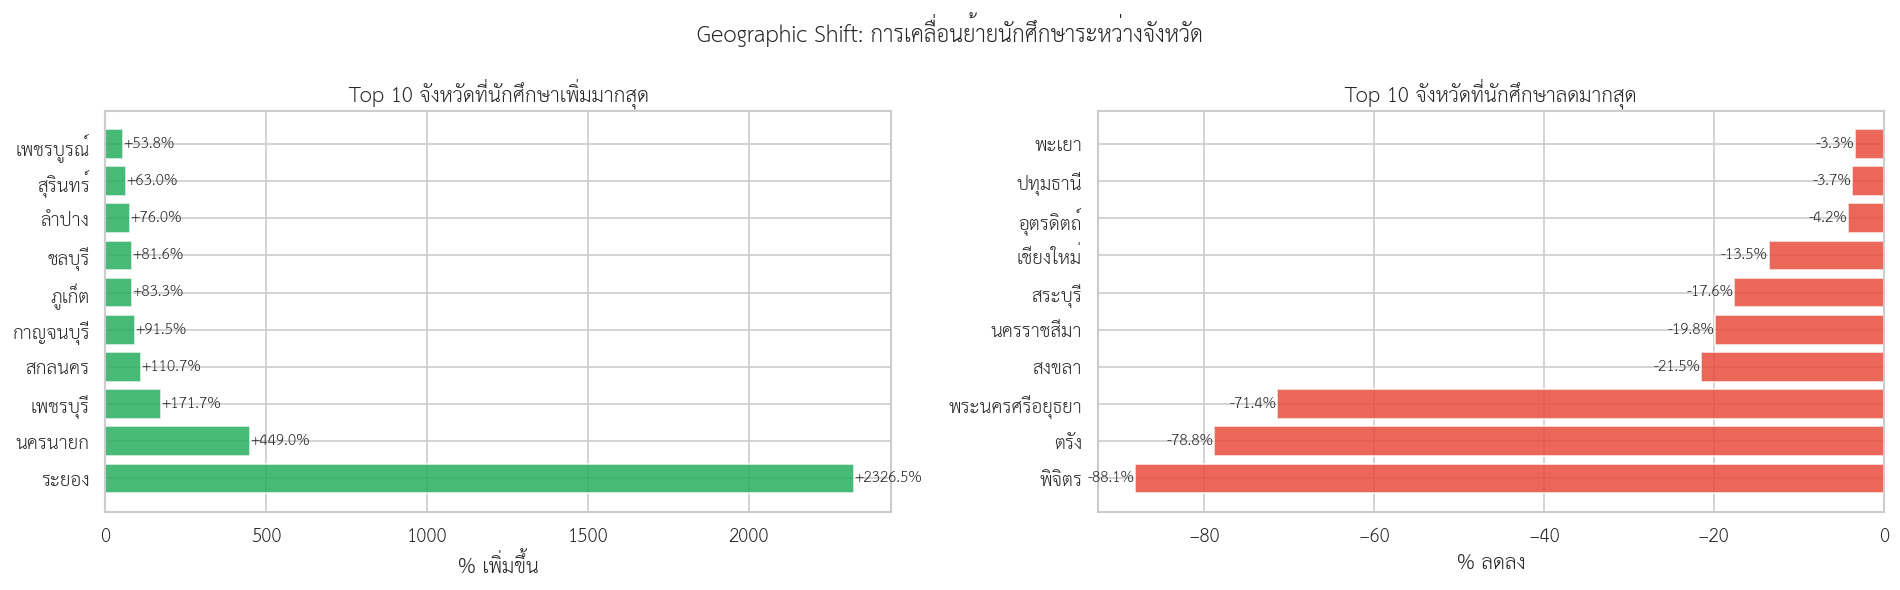

In [ ]:
# ค้นหาจังหวัดที่เติบโตและหดตัวมากที่สุด
prov_change = by_prov_year[by_prov_year[[2567, 2568]].min(axis=1) > 100].copy()

top_growth  = prov_change.nlargest(10, 'pct_change')
top_decline = prov_change.nsmallest(10, 'pct_change')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top_growth.index, top_growth['pct_change'], color='#27ae60', alpha=0.85)
axes[0].set_title('Top 10 จังหวัดที่นักศึกษาเพิ่มมากสุด', fontweight='bold')
axes[0].set_xlabel('% เพิ่มขึ้น')
for i, v in enumerate(top_growth['pct_change']):
    axes[0].text(v + 0.1, i, f'{v:+.1f}%', va='center', fontsize=9)

axes[1].barh(top_decline.index, top_decline['pct_change'], color='#e74c3c', alpha=0.85)
axes[1].set_title('Top 10 จังหวัดที่นักศึกษาลดมากสุด', fontweight='bold')
axes[1].set_xlabel('% ลดลง')
for i, v in enumerate(top_decline['pct_change']):
    axes[1].text(v - 0.1, i, f'{v:+.1f}%', va='center', ha='right', fontsize=9)

plt.suptitle('Geographic Shift: การเคลื่อนย้ายนักศึกษาระหว่างจังหวัด', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**สรุปผลการวิเคราะห์เชิงภูมิศาสตร์ — การเคลื่อนย้ายนักศึกษาระหว่างจังหวัด**

**📈 จังหวัดที่นักศึกษาเพิ่มขึ้นมากที่สุด**

ระยองโตสูงผิดปกติที่ +2,326% ซึ่งตัวเลขในระดับนี้โดยปกติไม่ได้เกิดจากการเติบโตตามธรรมชาติ แต่มักมีสาเหตุมาจาก การเปิดวิทยาเขตใหม่หรือสถาบันใหม่ ในจังหวัด ทำให้ฐานตัวเลขปี 2567 ต่ำมาก เมื่อมีนักศึกษาเพิ่มขึ้นแม้เพียงเล็กน้อยในเชิงสัมบูรณ์ % change จึงพุ่งสูงอย่างผิดสัดส่วน ควรตรวจสอบตัวเลขสัมบูรณ์ประกอบก่อนสรุป

นครนายก +449% และเพชรบุรี +171% มีลักษณะคล้ายกัน คือฐานเดิมต่ำมาก การเพิ่มขึ้นจึงดูสูงเป็นพิเศษเมื่อวัดเป็นเปอร์เซ็นต์

ชลบุรี +81.6% น่าสนใจที่สุดในกลุ่มนี้ เพราะเป็นจังหวัดที่มีฐานนักศึกษาใหญ่พอสมควรอยู่แล้ว การโตถึง 81% จึงสะท้อน การขยายตัวจริงของพื้นที่ EEC ไม่ใช่แค่ผลของฐานที่ต่ำ

**📉 จังหวัดที่นักศึกษาลดลงมากที่สุด**

พิจิตร -88.1%, ตรัง -78.8%, พระนครศรีอยุธยา -71.4% การลดลงในระดับนี้อาจเกิดจากการปิดตัวหรือย้ายสังกัดของสถาบันในจังหวัด มากกว่าที่นักศึกษาจะเลือกไม่เรียนในพื้นที่นั้น ควรตรวจสอบว่ามีสถาบันใดปิดตัวหรือควบรวมในช่วงเวลาดังกล่าวหรือไม่

สงขลา -21.5% และนครราชสีมา -19.8% น่าเป็นห่วงกว่ากลุ่มแรก เพราะทั้งสองจังหวัดเป็น ศูนย์กลางการศึกษาระดับภูมิภาค ที่มีฐานนักศึกษาขนาดใหญ่ การลดลงจึงสะท้อนการเปลี่ยนแปลงที่มีนัยสำคัญต่อระบบการศึกษาในภาคใต้และภาคอีสานตอนล่าง

เชียงใหม่ -13.5% เป็นสัญญาณที่ต้องติดตาม เพราะเชียงใหม่ถือเป็นศูนย์กลางการศึกษาที่ใหญ่ที่สุดของภาคเหนือ การลดลงในระดับนี้อาจสะท้อนปัจจัยเชิงเศรษฐกิจหรือการแข่งขันจากสถาบันในจังหวัดอื่นที่เพิ่มขึ้น


---


**⚠️ ข้อควรระวังในการตีความ**

ตัวเลข % change ที่สูงหรือต่ำผิดปกติ ไม่ควรตีความโดดๆ เสมอไป ควรดูควบคู่กับ จำนวนสัมบูรณ์ เสมอ เช่น ระยองโต +2,326% แต่ถ้าเพิ่มจากแค่ 100 คน เป็น 2,426 คน ผลกระทบต่อระบบโดยรวมยังน้อยมาก เมื่อเทียบกับกรุงเทพฯ ที่โตแค่ +1.3% แต่มีนักศึกษาเพิ่มขึ้นหลายหมื่นคนในเชิงสัมบูรณ์

In [ ]:
# เช็คสาขาที่เพิ่มมาในระยอง ปี 2568

# สร้าง province mapping จาก df_68 ก่อน
province_map = (
    df_68
    .groupby('UNIV_MASTERNAME_TH')['UNIV_PROVINCE_NAME']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

# เพิ่มคอลัมน์จังหวัดให้ df_67
df_67['UNIV_PROVINCE_NAME'] = df_67['UNIV_MASTERNAME_TH'].map(province_map)

# ─── จากนั้นรันโค้ดเดิมได้เลย ───
r67 = df_67[df_67['UNIV_PROVINCE_NAME'] == 'ระยอง']
r68 = df_68[df_68['UNIV_PROVINCE_NAME'] == 'ระยอง']

print('=' * 55)
print('📍 ระยอง ปี 2567')
print(f'   นักศึกษารวม : {r67["ALL STD"].sum():,} คน')
print(f'   จำนวนสถาบัน : {r67["UNIV_MASTERNAME_TH"].nunique()} แห่ง')
print()
print(r67.groupby('UNIV_MASTERNAME_TH')['ALL STD'].sum()
        .rename('นักศึกษา').to_frame().to_string())

print()
print('=' * 55)
print('📍 ระยอง ปี 2568')
print(f'   นักศึกษารวม : {r68["ALL STD"].sum():,} คน')
print(f'   จำนวนสถาบัน : {r68["UNIV_MASTERNAME_TH"].nunique()} แห่ง')
print()
print(r68.groupby('UNIV_MASTERNAME_TH')['ALL STD'].sum()
        .rename('นักศึกษา').to_frame().to_string())

univ_67 = set(r67['UNIV_MASTERNAME_TH'].unique())
univ_68 = set(r68['UNIV_MASTERNAME_TH'].unique())
new_univ = univ_68 - univ_67

print()


📍 ระยอง ปี 2567
   นักศึกษารวม : 275.0 คน
   จำนวนสถาบัน : 1 แห่ง

                    นักศึกษา
UNIV_MASTERNAME_TH          
สถาบันวิทยสิริเมธี     275.0

📍 ระยอง ปี 2568
   นักศึกษารวม : 6,673.0 คน
   จำนวนสถาบัน : 4 แห่ง

                                            นักศึกษา
UNIV_MASTERNAME_TH                                  
มหาวิทยาลัยเฉลิมกาญจนา                        1285.0
มหาวิทยาลัยเทคโนโลยีพระจอมเกล้าพระนครเหนือ    5094.0
สถาบันบัณฑิตพัฒนบริหารศาสตร์                    29.0
สถาบันวิทยสิริเมธี                             265.0



### 5.3 ⚥ Gender Analysis — สัดส่วนเพศในแต่ละสาขา

การวิเคราะห์สัดส่วนเพศในระดับอุดมศึกษาช่วยให้เห็นว่าความไม่เท่าเทียมทางเพศยังซ่อนอยู่ในระดับสาขาวิชา แม้ภาพรวมจะดูสมดุล — สาขาไหนที่ผู้ชายหรือผู้หญิงครองอยู่ฝ่ายเดียว และแนวโน้มนั้นกำลังเปลี่ยนไปหรือไม่ คือสิ่งที่ตัวเลขจะบอกเรา

In [ ]:
# สัดส่วนเพศรวม
gender_total = df_all.groupby(['ACADEMIC_YEAR', 'GENDER_NAME'])['ALL STD'].sum().unstack()
gender_total['total'] = gender_total.sum(axis=1)
gender_total['% หญิง'] = gender_total['หญิง'] / gender_total['total'] * 100

print('⚥ สัดส่วนนักศึกษาหญิงทั่วประเทศ:')
for yr, row in gender_total.iterrows():
    bar_len = int(row['% หญิง'] / 2)
    print(f'   ปี {yr}: หญิง {row["% หญิง"]:.1f}% | {"█"*bar_len}{"░"*(50-bar_len)}')

⚥ สัดส่วนนักศึกษาหญิงทั่วประเทศ:
   ปี 2567: หญิง 59.1% | █████████████████████████████░░░░░░░░░░░░░░░░░░░░░
   ปี 2568: หญิง 59.1% | █████████████████████████████░░░░░░░░░░░░░░░░░░░░░


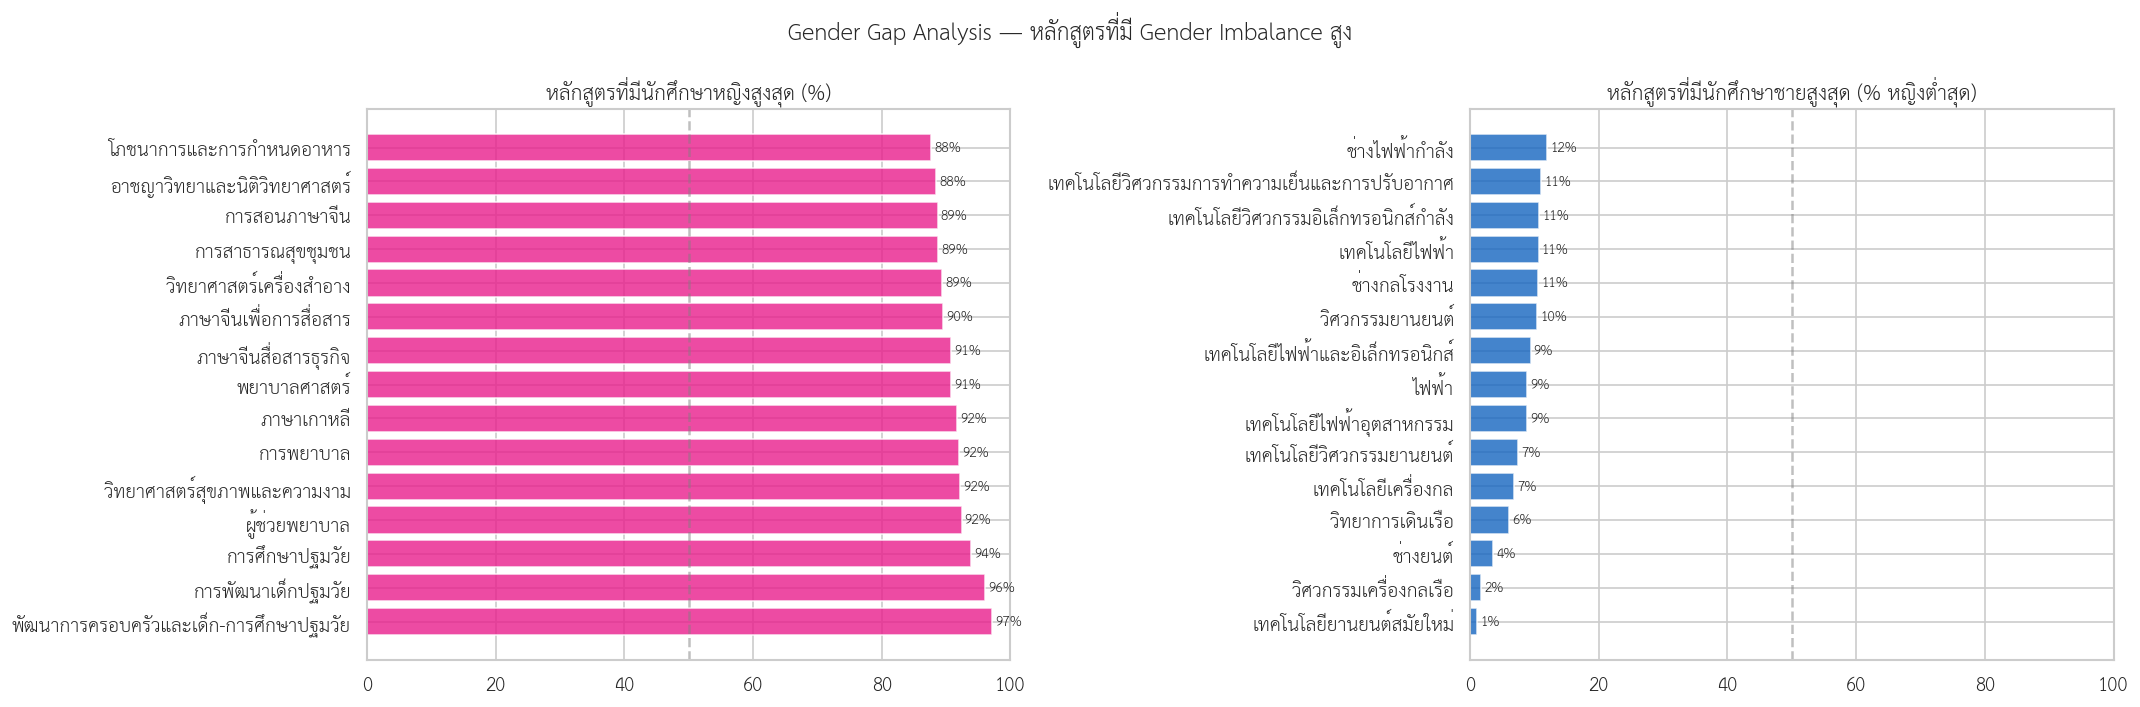

In [ ]:
# Top 15 หลักสูตรที่มีนักศึกษาหญิงสูงสุด vs ต่ำสุด (ปี 2568)
gender_prog = (
    df_all[df_all['ACADEMIC_YEAR'] == 2568]
    .groupby(['PROGRAM_NAME', 'GENDER_NAME'])['ALL STD']
    .sum().unstack(fill_value=0)
)
gender_prog['total'] = gender_prog.sum(axis=1)
gender_prog['pct_female'] = gender_prog.get('หญิง', 0) / gender_prog['total'] * 100
gender_prog = gender_prog[gender_prog['total'] >= 500]  # กรองหลักสูตรที่มีนักศึกษาพอ

top_female  = gender_prog.nlargest(15, 'pct_female')
top_male    = gender_prog.nsmallest(15, 'pct_female')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(top_female.index, top_female['pct_female'], color='#e91e8c', alpha=0.8)
axes[0].set_xlim(0, 100)
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('หลักสูตรที่มีนักศึกษาหญิงสูงสุด (%)', fontweight='bold')
for i, v in enumerate(top_female['pct_female']):
    axes[0].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)

axes[1].barh(top_male.index, top_male['pct_female'], color='#1565C0', alpha=0.8)
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('หลักสูตรที่มีนักศึกษาชายสูงสุด (% หญิงต่ำสุด)', fontweight='bold')
for i, v in enumerate(top_male['pct_female']):
    axes[1].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)

plt.suptitle('Gender Gap Analysis — หลักสูตรที่มี Gender Imbalance สูง', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**สรุป Gender Analysis**

ภาพรวมที่กราฟบอก
ระบบอุดมศึกษาไทยมี Gender Gap ที่ชัดเจน แต่แยกตามสายวิชา ไม่ใช่ภาพรวมทั้งระบบ

👩 สายที่ผู้หญิงครอง
สาขาที่ผู้หญิงสูงสุดล้วนอยู่ในกลุ่ม Care & Language ทั้งสิ้น


👨 สายที่ผู้ชายครอง
สาขาที่ผู้ชายสูงสุดล้วนอยู่ในกลุ่ม ช่างและวิศวกรรม ทั้งสิ้น

**💡 ข้อสรุปสำคัญ**

Gender Gap ในไทยไม่ได้อยู่ที่การเข้าถึงการศึกษา แต่อยู่ที่การเลือกสาขา — ผู้หญิงเข้าถึงมหาวิทยาลัยได้มากกว่าผู้ชายในภาพรวม แต่ทั้งสองเพศยังคงเลือกสายวิชาตาม บทบาทที่สังคมคาดหวัง อย่างชัดเจน ซึ่งส่งผลต่อความเหลื่อมล้ำทางรายได้ในตลาดแรงงานต่อไป เพราะสาขาวิศวกรรมและเทคนิคมักมีค่าตอบแทนสูงกว่าสาขา Care Economy อย่างมีนัยสำคัญ

### 5.4 🎓 Level of Study Analysis — สัดส่วนระดับการศึกษา

การวิเคราะห์สัดส่วนระดับการศึกษาช่วยสะท้อนโครงสร้างของระบบอุดมศึกษา ทั้งในแง่ที่ว่าระบบยังคงเน้นการผลิตบัณฑิตระดับปริญญาตรีเป็นหลักหรือไม่ จำนวนนักศึกษาระดับบัณฑิตศึกษามีแนวโน้มเพิ่มขึ้นหรือไม่ และสถาบันประเภทใดที่มีสัดส่วนนักศึกษาระดับปริญญาโทและเอกสูง ซึ่งเป็นตัวชี้วัดสำคัญของความเข้มข้นด้านการวิจัยและพัฒนาของสถาบันนั้น

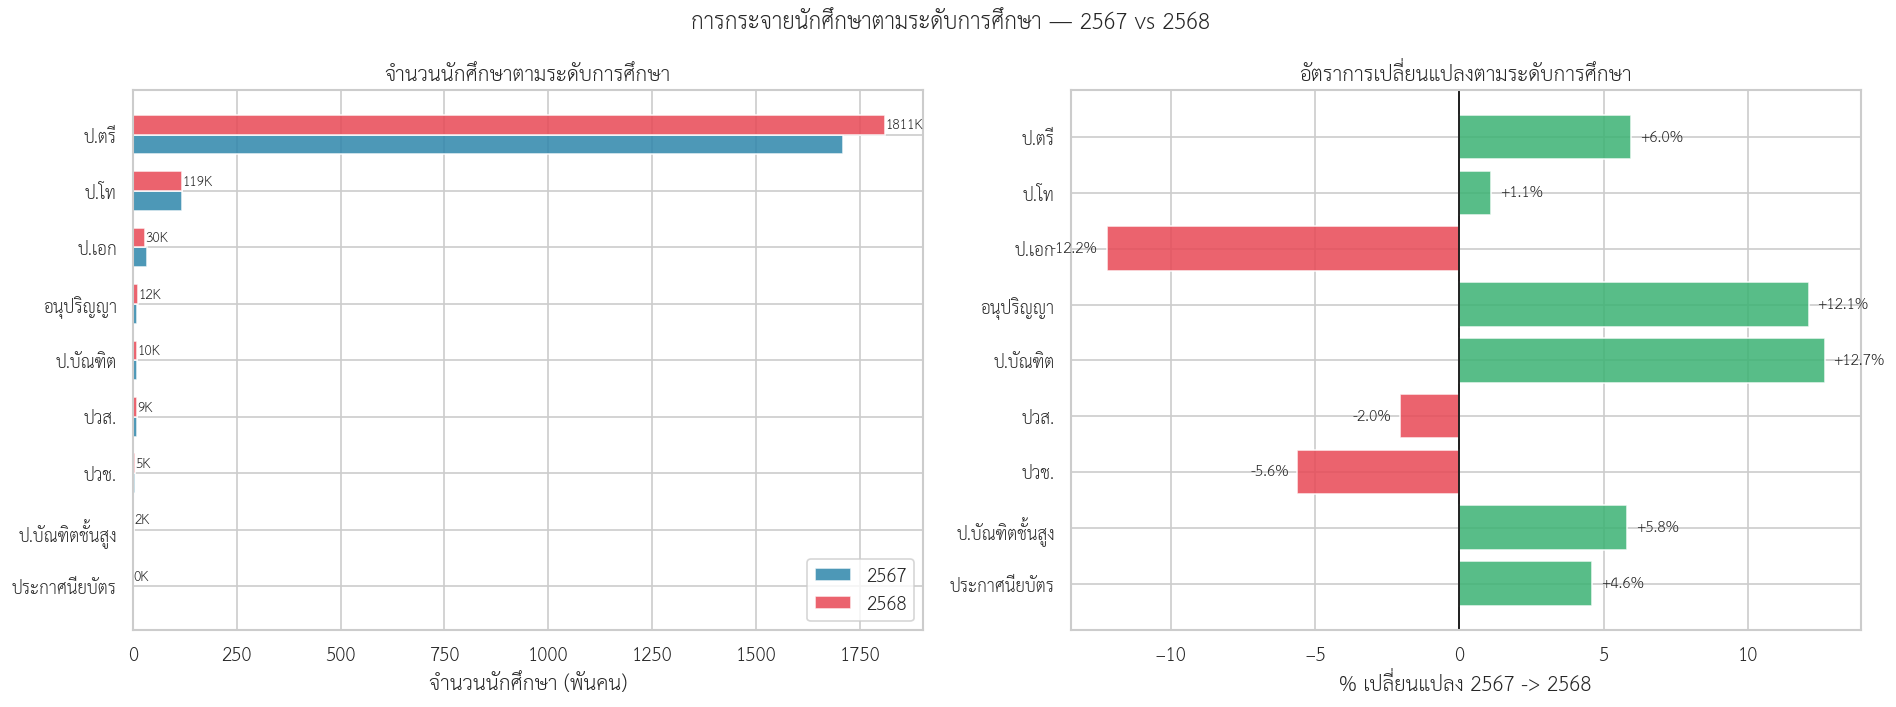

In [ ]:
# สัดส่วนระดับการศึกษา
# เตรียมข้อมูล
lev_year = (
    df_all.groupby(['LEV_NAME_TH', 'ACADEMIC_YEAR'])['ALL STD']
    .sum().unstack('ACADEMIC_YEAR').fillna(0)
)
lev_year.columns = [int(c) for c in lev_year.columns]
lev_year['total'] = lev_year.sum(axis=1)
lev_year = lev_year.sort_values('total', ascending=True).drop(columns='total')

# คำนวณ % สัดส่วน
lev_pct = lev_year.div(lev_year.sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── กราฟซ้าย: จำนวนสัมบูรณ์ ──
x = np.arange(len(lev_year))
w = 0.35
axes[0].barh(x - w/2, lev_year[2567] / 1000, w, label='2567', color='#2E86AB', alpha=0.85)
axes[0].barh(x + w/2, lev_year[2568] / 1000, w, label='2568', color='#E84855', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(lev_year.index, fontsize=10)
axes[0].set_xlabel('จำนวนนักศึกษา (พันคน)')
axes[0].set_title('จำนวนนักศึกษาตามระดับการศึกษา', fontweight='bold')
axes[0].legend()
for i, (v67, v68) in enumerate(zip(lev_year[2567], lev_year[2568])):
    axes[0].text(v68/1000 + 0.5, i + w/2, f'{v68/1000:.0f}K', va='center', fontsize=8)

# ── กราฟขวา: % เปลี่ยนแปลง ──
pct_change = (lev_year[2568] - lev_year[2567]) / (lev_year[2567] + 1) * 100
colors_bar = ['#3BB273' if v >= 0 else '#E84855' for v in pct_change]
axes[1].barh(x, pct_change, color=colors_bar, alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_yticks(x)
axes[1].set_yticklabels(lev_year.index, fontsize=10)
axes[1].set_xlabel('% เปลี่ยนแปลง 2567 -> 2568')
axes[1].set_title('อัตราการเปลี่ยนแปลงตามระดับการศึกษา', fontweight='bold')
for i, v in enumerate(pct_change):
    axes[1].text(v + (0.3 if v >= 0 else -0.3), i, f'{v:+.1f}%',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('การกระจายนักศึกษาตามระดับการศึกษา — 2567 vs 2568',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**สรุป Level of Study Analysis**

โครงสร้างระบบยังคงเน้น ป.ตรี เป็นหลัก

**ปริญญาตรี**ครองสัดส่วน 90% ของนักศึกษาทั้งระบบในทั้งสองปี และยังคงเติบโตต่อเนื่องที่ +6% สะท้อนว่าโครงสร้างพื้นฐานของระบบอุดมศึกษาไทยยังไม่เปลี่ยนแปลงเชิงโครงสร้างแต่อย่างใด

สัญญาณที่น่าสนใจ
**ป.เอก** ลดลง -12.2% — น่าเป็นห่วงที่สุดในกราฟนี้ เพราะสะท้อนว่าความสนใจในการทำวิจัยระดับสูงของประเทศกำลังลดลง ซึ่งมีผลกระทบต่อขีดความสามารถในการแข่งขันด้านนวัตกรรมและงานวิจัยในระยะยาว

**ป.บัณฑิต** +12.7% และ**อนุปริญญา** +12.1% — เติบโตเร็วที่สุด สะท้อนความต้องการใบรับรองวิชาชีพเฉพาะทางที่ใช้เวลาสั้นกว่าปริญญา ซึ่งสอดคล้องกับแนวโน้ม Upskilling ของตลาดแรงงานที่ต้องการทักษะเฉพาะด้านอย่างรวดเร็ว

**ปวช.** และ**ปวส.** ลดลง — สายอาชีวศึกษาในระบบอุดมศึกษาหดตัวต่อเนื่อง อาจสะท้อนว่านักศึกษาเลือกเรียนต่อในระดับปริญญาตรีโดยตรงมากขึ้น

In [ ]:
# ระดับ ป.โท / ป.เอก แยกตามประเภทมหาวิทยาลัย — ใครเป็น Research University จริงๆ?
grad_filter = df_all[df_all['LEV_NAME_TH'].isin(['ป.โท', 'ป.เอก'])]
grad_by_type = grad_filter.groupby(['UNIV_TYPE_NAME', 'LEV_NAME_TH', 'ACADEMIC_YEAR'])['ALL STD'].sum().reset_index()

fig = px.bar(
    grad_by_type,
    x='UNIV_TYPE_NAME', y='ALL STD', color='LEV_NAME_TH',
    facet_col='ACADEMIC_YEAR', barmode='group',
    color_discrete_map={'ป.โท': '#9b59b6', 'ป.เอก': '#2c3e50'},
    title='🔬 Graduate Students (ป.โท & ป.เอก) แยกตามประเภทสถาบัน',
    labels={'UNIV_TYPE_NAME': 'ประเภทสถาบัน', 'ALL STD': 'จำนวนนักศึกษา'},
    height=500
)
fig.update_xaxes(tickangle=30)
fig.show()

**สรุป Graduate Students Analysis**

**มหาวิทยาลัยรัฐในกำกับ**ครองตลาดบัณฑิตศึกษา

ป.โท: รัฐในกำกับมีนักศึกษาสูงสุดประมาณ 57,000 คน ในปี 2567 แต่ลดลงเหลือ 54,000 คน ในปี 2568 สะท้อนแนวโน้มที่น่ากังวลสำหรับสถาบันชั้นนำ

ป.เอก: รัฐในกำกับครองอันดับ 1 เช่นกันที่ประมาณ 20,000 คน แต่ลดลงอย่างชัดเจนในปี 2568 เหลือประมาณ 17,000 คน ซึ่งสอดคล้องกับตัวเลข -12.2% จากกราฟก่อนหน้า

**สัญญาณที่น่าสนใจ**

**มหาวิทยาลัยเอกชน**โตขึ้นชัดเจน — ป.โท เพิ่มจาก 25,000 → 28,000 คน และป.เอก เพิ่มจาก 6,000 → ประมาณ 6,500 คน สะท้อนว่าเอกชนกำลังขยายตลาดบัณฑิตศึกษาอย่างจริงจัง ไม่ใช่แค่ระดับปริญญาตรี

**ราชภัฏ**มีป.โทเป็นอันดับ 3 ที่ประมาณ 10,000–13,000 คน แสดงว่าราชภัฏไม่ได้เป็นแค่สถาบันปริญญาตรีอีกต่อไป แต่กำลังขยับขึ้นมาแข่งในตลาดบัณฑิตศึกษาด้วย

### 5.5 🏆 University Ranking & Market Share Analysis

การวิเคราะห์ส่วนแบ่งตลาดของแต่ละสถาบันช่วยให้เข้าใจว่าสถาบันใดมีบทบาทหลักในระบบอุดมศึกษาไทย และสถาบันใดมีแนวโน้มขยายตัวหรือหดตัว ซึ่งข้อมูลดังกล่าวมีประโยชน์ทั้งในเชิงนโยบายสำหรับหน่วยงานที่เกี่ยวข้อง และในเชิงการตัดสินใจเลือกศึกษาต่อของผู้เรียน

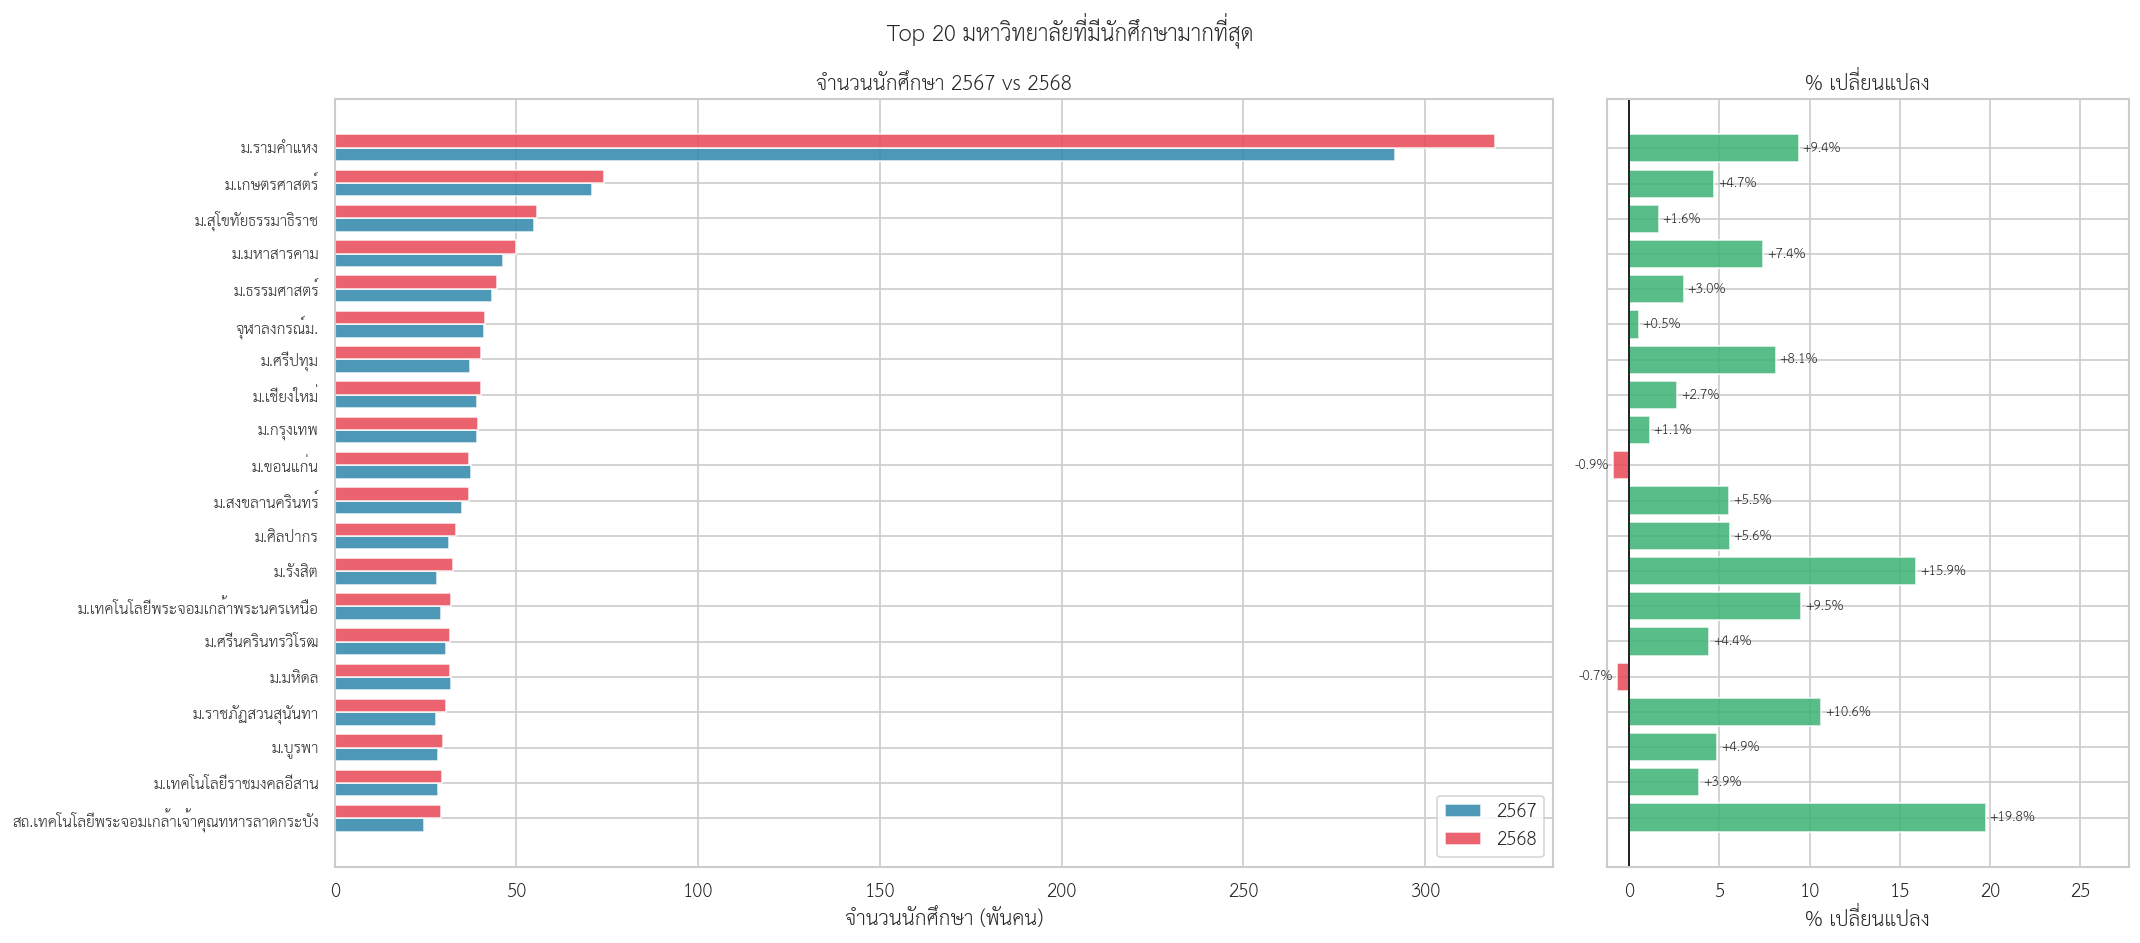

In [ ]:
# Top 20 มหาวิทยาลัยที่มีนักศึกษามากสุด
top_univ = (
    df_all.groupby(['UNIV_MASTERNAME_TH', 'ACADEMIC_YEAR'])['ALL STD']
    .sum().unstack(1)
)
top_univ.columns = [int(c) for c in top_univ.columns]
top_univ = top_univ.fillna(0)
top_univ['total'] = top_univ.sum(axis=1)
top_univ['pct_change'] = (top_univ[2568] - top_univ[2567]) / (top_univ[2567] + 1) * 100
top20_univ = top_univ.nlargest(20, 'total').reset_index()
top20_univ = top20_univ.sort_values(2568, ascending=True)
top20_univ['ชื่อย่อ'] = top20_univ['UNIV_MASTERNAME_TH'].str.replace(
    'มหาวิทยาลัย', 'ม.').str.replace('สถาบัน', 'สถ.')

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [7, 3]})

# ── ซ้าย: จำนวน ──
x = np.arange(len(top20_univ))
w = 0.38
axes[0].barh(x - w/2, top20_univ[2567] / 1000, w, label='2567', color='#2E86AB', alpha=0.85)
axes[0].barh(x + w/2, top20_univ[2568] / 1000, w, label='2568', color='#E84855', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top20_univ['ชื่อย่อ'], fontsize=9)
axes[0].set_xlabel('จำนวนนักศึกษา (พันคน)')
axes[0].set_title('จำนวนนักศึกษา 2567 vs 2568', fontweight='bold')
axes[0].legend()

# ── ขวา: % change ──
colors = ['#3BB273' if v >= 0 else '#E84855' for v in top20_univ['pct_change']]
axes[1].barh(x, top20_univ['pct_change'], color=colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_yticks(x)
axes[1].set_yticklabels([])   # ซ่อน label ซ้ำ
axes[1].set_xlabel('% เปลี่ยนแปลง')
axes[1].set_title('% เปลี่ยนแปลง', fontweight='bold')

x_min = top20_univ['pct_change'].min()
x_max = top20_univ['pct_change'].max()
axes[1].set_xlim(x_min * 1.4, x_max * 1.4)
for i, v in enumerate(top20_univ['pct_change']):
    axes[1].text(v + (0.2 if v >= 0 else -0.2), i, f'{v:+.1f}%',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.suptitle('Top 20 มหาวิทยาลัยที่มีนักศึกษามากที่สุด', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**ม.รามคำแหง** ครองตลาดอย่างเบ็ดเสร็จด้วยนักศึกษากว่า 300,000 คน ห่างจากอันดับ 2 ถึง 4 เท่า และยังโตต่อเนื่อง +9.4% ขณะที่กลุ่มกลางอย่าง **เกษตร สุโขทัย และมหาสารคาม** เติบโตสม่ำเสมอในช่วง +1.6% ถึง +7.4% สวนทางกับจุฬาฯ ที่โตเพียง +0.5% และ **ม.ขอนแก่น ม.มหิดล** ที่ติดลบเล็กน้อย ในขณะที่ **สจล.** โตเร็วที่สุดในกลุ่มที่ +19.8% และ **ม.รังสิต** +15.9% บ่งชี้ว่าสถาบันที่ตอบสนองตลาดได้เร็วกำลังไล่ตามสถาบันชั้นนำอย่างมีนัยสำคัญ

### 5.6 🔥 Heatmap: ความหนาแน่นนักศึกษาตามประเภทสถาบัน × จังหวัด

**แผนภาพความร้อน (Heatmap)**
เป็นเครื่องมือที่เหมาะสำหรับการแสดงความสัมพันธ์เชิงเมทริกซ์ระหว่างสองตัวแปรพร้อมกัน ในที่นี้ใช้เพื่อวิเคราะห์ว่าสถาบันแต่ละประเภทมีการกระจายตัวในจังหวัดใดบ้าง ซึ่งจะเผยให้เห็นรูปแบบที่ชัดเจน เช่น มหาวิทยาลัยราชภัฏที่กระจายครอบคลุมทั่วทุกภูมิภาค เปรียบเทียบกับมหาวิทยาลัยรัฐในกำกับที่กระจุกตัวอยู่เฉพาะในเมืองใหญ่

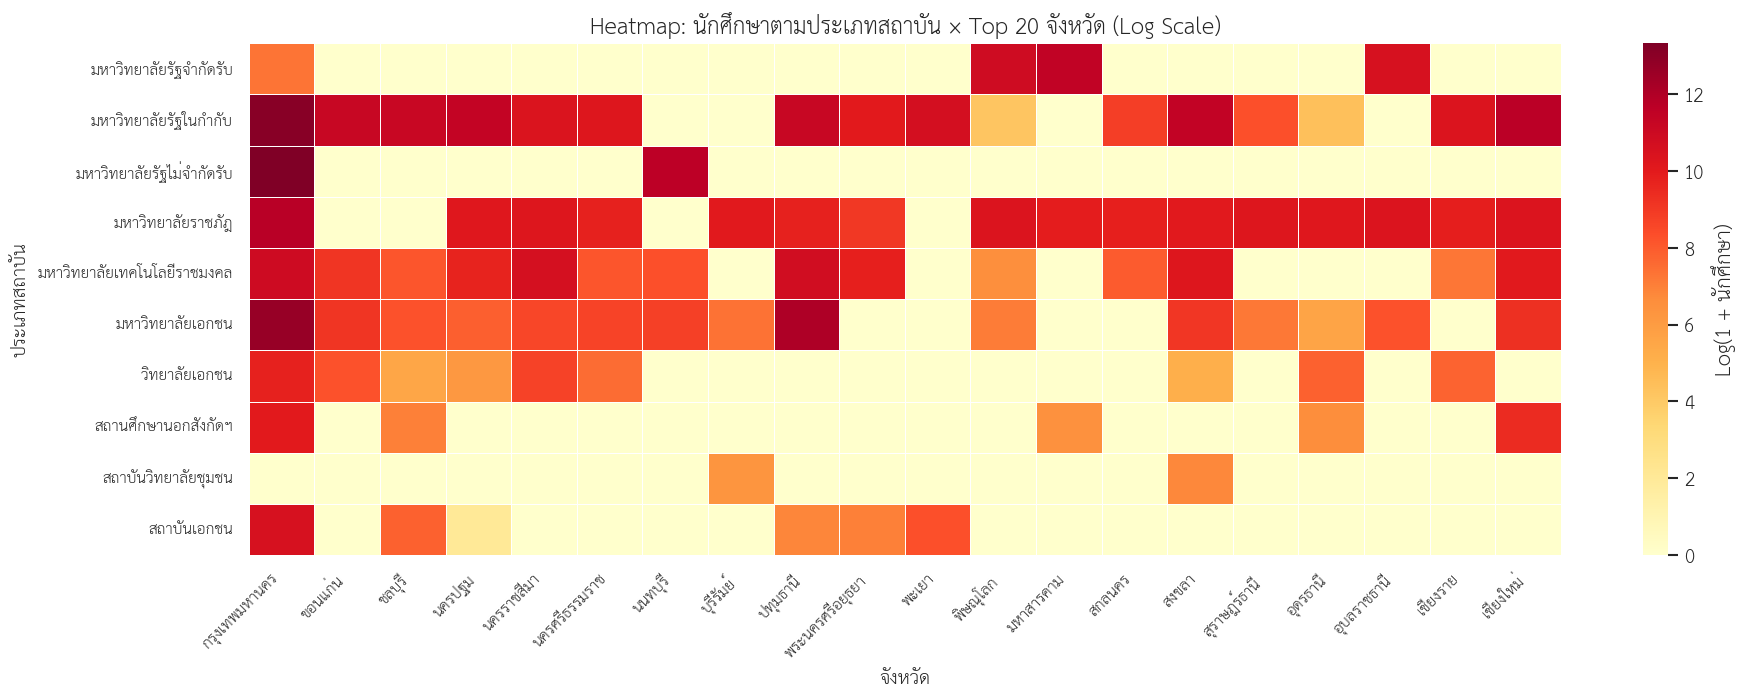

In [ ]:
# Heatmap: ประเภทสถาบัน vs จังหวัด (top 20 จังหวัด)
top20_prov = df_all.groupby('UNIV_PROVINCE_NAME')['ALL STD'].sum().nlargest(20).index

heat_data = (
    df_all[df_all['UNIV_PROVINCE_NAME'].isin(top20_prov)]
    .groupby(['UNIV_TYPE_NAME', 'UNIV_PROVINCE_NAME'])['ALL STD']
    .sum().unstack(fill_value=0)
)

# Log transform เพื่อลด dominance ของค่าสูงมาก 💡 หลักการ: ใช้ Log Transform เมื่อข้อมูลมีช่วงกว้างมาก เพื่อให้ทุกค่ามีโอกาส "ถูกมองเห็น" บนกราฟอย่างเท่าเทียมกัน
heat_log = np.log1p(heat_data)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heat_log,
    cmap='YlOrRd',
    linewidths=0.3,
    annot=False,
    fmt='.0f',
    cbar_kws={'label': 'Log(1 + นักศึกษา)'}
)
plt.title('Heatmap: นักศึกษาตามประเภทสถาบัน × Top 20 จังหวัด (Log Scale)',
          fontsize=13, fontweight='bold')
plt.xlabel('จังหวัด', fontsize=11)
plt.ylabel('ประเภทสถาบัน', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**สรุป Heatmap Analysis**

Pattern ที่เห็นชัดแต่ละประเภทสถาบัน

**มหาวิทยาลัยรัฐในกำกับ** — กระจายอยู่เกือบทุกแถวสีเข้ม แต่เฉพาะเมืองใหญ่เท่านั้น เช่น กรุงเทพฯ ขอนแก่น เชียงใหม่ สงขลา สะท้อนว่ากลุ่มนี้ ไม่ได้กระจายตัวตามภูมิภาค แต่กระจุกอยู่ในศูนย์กลางเศรษฐกิจ

**มหาวิทยาลัยราชภัฏ** — มีสีปรากฏเกือบทุกจังหวัดในแถว สอดคล้องกับพันธกิจที่ตั้งใจให้ 1 จังหวัด มีราชภัฏอย่างน้อย 1 แห่ง เป็นหลักฐานว่านโยบายกระจายการศึกษาออกสู่ภูมิภาคได้ผลจริงในกลุ่มนี้

**มหาวิทยาลัยเอกชน** — กระจุกหนักที่กรุงเทพฯ และปริมณฑล แต่เริ่มขยายไปบุรีรัมย์และจังหวัดใหญ่ในภูมิภาค สะท้อนการ ขยายตลาดออกนอก กทม. ของเอกชนในระยะหลัง

**ราชมงคล** — กระจายค่อนข้างสม่ำเสมอตามจังหวัดอุตสาหกรรม เช่น ชลบุรี นครราชสีมา สอดคล้องกับพันธกิจด้านวิศวกรรมและเทคนิค

**สถาบันวิทยาลัยชุมชน** — มีเพียงไม่กี่จังหวัดและสีอ่อน สะท้อนว่ายังมีขนาดเล็กและครอบคลุมไม่ทั่วถึง


---


**ข้อสรุป**

Heatmap นี้เผยให้เห็น ความเหลื่อมล้ำเชิงโครงสร้าง อย่างชัดเจน — สถาบันที่มีคุณภาพสูงและทรัพยากรมากกระจุกอยู่ในเมืองใหญ่ ขณะที่ต่างจังหวัดพึ่งพาราชภัฏและราชมงคลเป็นหลัก ซึ่งสะท้อนว่าโอกาสในการเข้าถึงสถาบันที่หลากหลายยังไม่เท่าเทียมกันตามภูมิภาค

### 5.7 📉 Trend Analysis: Faculty Growth/Decline

การวิเคราะห์ในระดับคณะวิชาช่วยให้เห็นการเปลี่ยนแปลงเชิงโครงสร้างของระบบการศึกษา ว่าคณะใดได้รับความนิยมเพิ่มขึ้นและคณะใดมีแนวโน้มหดตัว ซึ่งสะท้อนทั้งทิศทางความต้องการของตลาดแรงงานและการเปลี่ยนแปลงของสังคมในภาพรวม

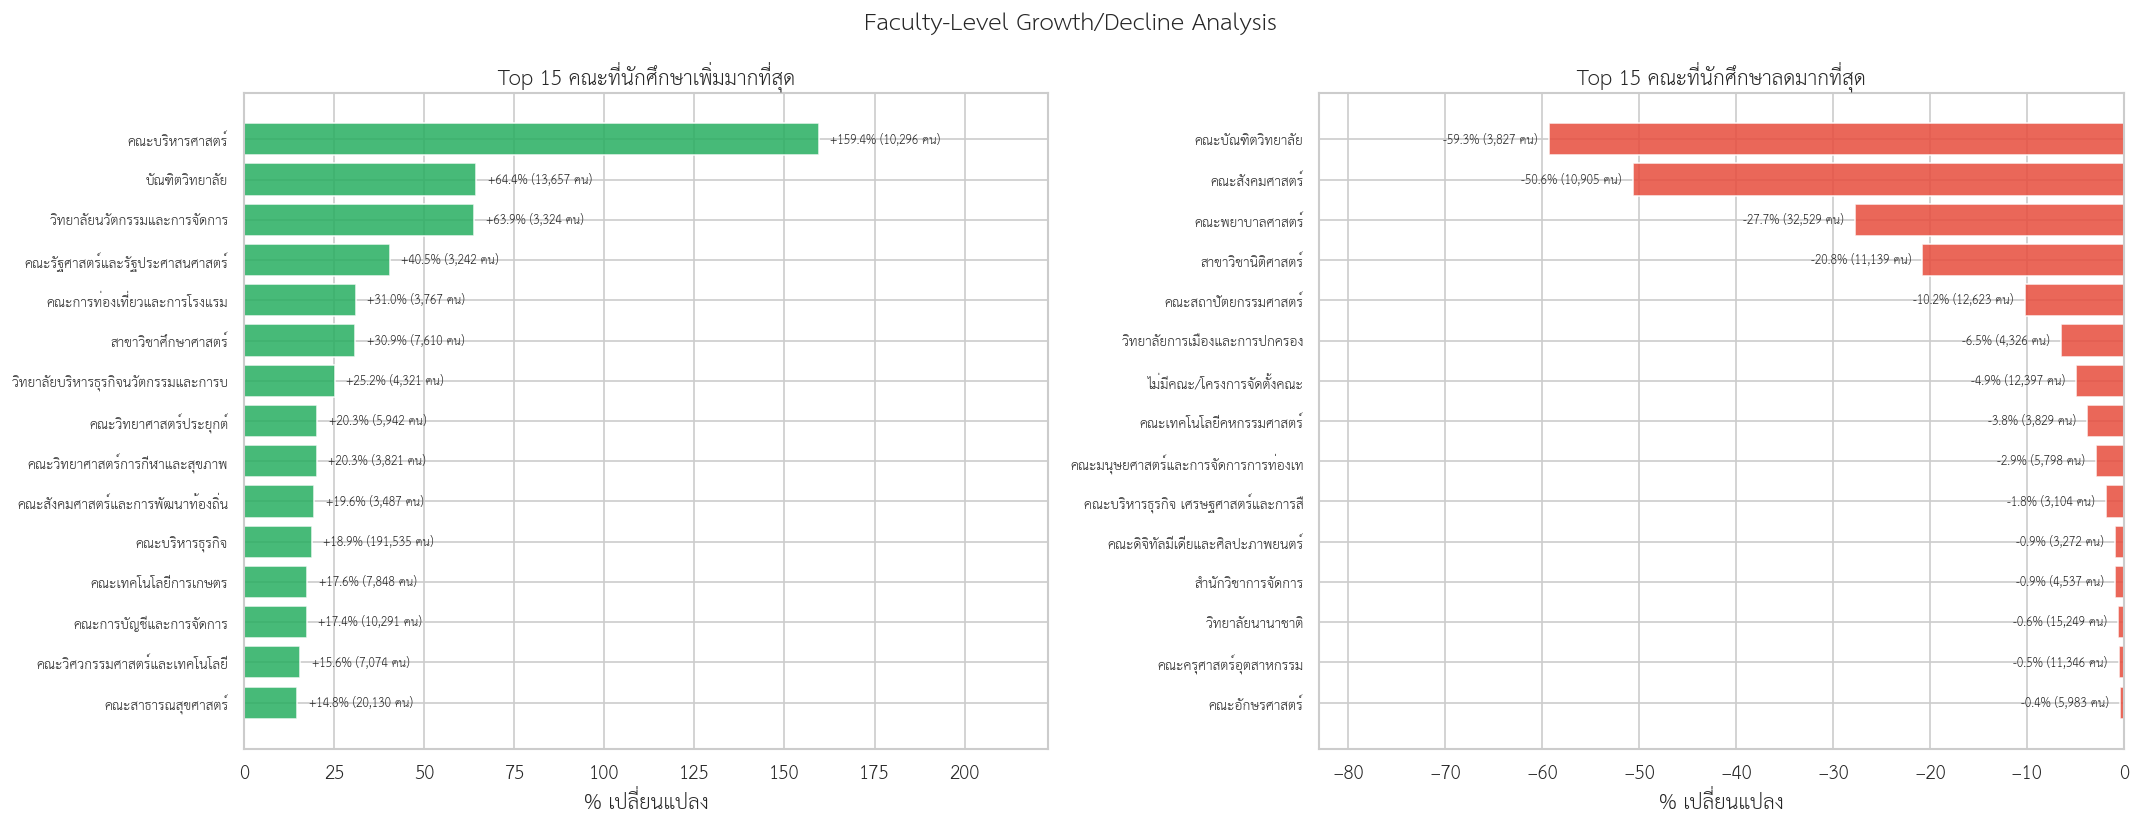

In [ ]:
fac_by_year = (
    df_all.groupby(['FAC_NAME', 'ACADEMIC_YEAR'])['ALL STD']
    .sum()
    .unstack('ACADEMIC_YEAR')
)
fac_by_year.columns = [int(c) for c in fac_by_year.columns]
fac_by_year = fac_by_year.fillna(0)
fac_by_year['total_68'] = fac_by_year[2568]
fac_by_year['pct_change'] = (
    (fac_by_year[2568] - fac_by_year[2567]) / (fac_by_year[2567] + 1) * 100
)
#เงื่อนไข total_68 >= 3,000 หมายความว่า คณะที่จะติด Top 15 ต้องมีนักศึกษาปี 2568 อย่างน้อย 3,000 คน จึงมั่นใจได้ว่าผลที่เห็นสะท้อนการเปลี่ยนแปลงที่มีนัยสำคัญต่อระบบจริงๆ
fac_filtered    = fac_by_year[fac_by_year['total_68'] >= 3000]
top_decline_fac = fac_filtered.nsmallest(15, 'pct_change').sort_values('pct_change', ascending=False)
top_growth_fac = fac_filtered.nlargest(15, 'pct_change').sort_values('pct_change', ascending=True )

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Growth ──
axes[0].barh(range(len(top_growth_fac)), top_growth_fac['pct_change'],
             color='#27ae60', alpha=0.85)
axes[0].set_yticks(range(len(top_growth_fac)))
axes[0].set_yticklabels([t[:35] for t in top_growth_fac.index], fontsize=8)
axes[0].set_title('Top 15 คณะที่นักศึกษาเพิ่มมากที่สุด', fontweight='bold')
axes[0].set_xlabel('% เปลี่ยนแปลง')
x_max = top_growth_fac['pct_change'].max()
axes[0].set_xlim(0, x_max * 1.4)
for i, (idx, row) in enumerate(top_growth_fac.iterrows()):
    v, n = row['pct_change'], row['total_68']
    axes[0].text(v + x_max * 0.02, i,
                f'+{v:.1f}% ({n:,.0f} คน)',
                va='center', fontsize=7, clip_on=False)

# ── Right: Decline ──
axes[1].barh(range(len(top_decline_fac)), top_decline_fac['pct_change'],
             color='#e74c3c', alpha=0.85)
axes[1].set_yticks(range(len(top_decline_fac)))
axes[1].set_yticklabels([t[:35] for t in top_decline_fac.index], fontsize=8)
axes[1].set_title('Top 15 คณะที่นักศึกษาลดมากที่สุด', fontweight='bold')
axes[1].set_xlabel('% เปลี่ยนแปลง')
x_min = top_decline_fac['pct_change'].min()
axes[1].set_xlim(x_min * 1.4, 0)                          # ← 1.35 → 1.4
for i, (idx, row) in enumerate(top_decline_fac.iterrows()):
    v, n = row['pct_change'], row['total_68']
    axes[1].text(v - abs(x_min) * 0.02, i,                # ← แก้ offset ให้ถูกทิศ
                f'{v:.1f}% ({n:,.0f} คน)',
                va='center', ha='right', fontsize=7, clip_on=False)  # ← เพิ่ม clip_on=False

plt.suptitle('Faculty-Level Growth/Decline Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.8 🔍 Advanced Insight: Concentration Index (HHI)

**ดัชนี Herfindahl-Hirschman (HHI)** เป็นเครื่องมือจากศาสตร์เศรษฐศาสตร์อุตสาหกรรมที่ใช้วัดระดับการกระจุกตัวของตลาด โดยค่าที่สูงบ่งชี้ว่านักศึกษาส่วนใหญ่กระจุกอยู่ในสถาบันเพียงไม่กี่แห่ง ในขณะที่ค่าต่ำสะท้อนการกระจายตัวที่สมดุลมากกว่า การนำ HHI มาประยุกต์ใช้กับข้อมูลนักศึกษาในระดับจังหวัด ช่วยให้เห็นว่าพื้นที่ใดมีลักษณะผูกขาดทางการศึกษา และพื้นที่ใดมีการแข่งขันระหว่างสถาบันอย่างแท้จริง


### สูตรคำนวณ HHI

ดัชนี HHI คำนวณจากผลรวมของส่วนแบ่งตลาดยกกำลังสอง

$$HHI = \sum_{i=1}^{n} s_i^2$$

โดยที่ $s_i$ คือสัดส่วนนักศึกษาของสถาบันที่ $i$
และ $n$ คือจำนวนสถาบันทั้งหมดในจังหวัดนั้น

ค่า HHI อยู่ระหว่าง $\frac{1}{n}$ ถึง $1.0$

**การแปลค่า HHI**


HHI = 1.0 ผูกขาด 100% — มีสถาบันเดียวในจังหวัด

HHI > 0.5  กระจุกตัวสูงมาก

HHI 0.25–0.5  กระจุกตัวปานกลาง

HHI < 0.25  แข่งขันสูง กระจายดี

In [ ]:
# คำนวณ HHI ตามจังหวัด (ใช้ข้อมูลปี 2568)

df_68_clean = df_68c.copy()

def hhi(group):
    total = group.sum()
    if total == 0:
        return 0
    shares = group / total
    return (shares ** 2).sum()

hhi_by_prov = (
    df_68_clean
    .groupby(['UNIV_PROVINCE_NAME', 'UNIV_MASTERNAME_TH'])['ALL STD']
    .sum()
    .groupby(level=0)
    .agg(hhi)
    .reset_index()
)
hhi_by_prov.columns = ['จังหวัด', 'HHI']
hhi_by_prov = hhi_by_prov.sort_values('HHI', ascending=False)



fig = px.bar(
    hhi_by_prov.head(25),
    x='จังหวัด', y='HHI',
    color='HHI',
    color_continuous_scale='Reds',
    title='📊 HHI (Concentration Index) ตามจังหวัด — สูง = กระจุกตัวมาก (ปี 2568)',
    height=450
)
fig.add_hline(y=0.25, line_dash='dash', line_color='gray',
              annotation_text='Threshold: Moderate Concentration (0.25)',
              annotation_position='top right')
fig.update_xaxes(tickangle=45)
fig.show()
print('💡 HHI > 0.25 = ตลาดกระจุกตัว | HHI < 0.15 = ตลาดแข่งขันสูง')

💡 HHI > 0.25 = ตลาดกระจุกตัว | HHI < 0.15 = ตลาดแข่งขันสูง


In [ ]:
fig = px.bar(
    hhi_by_prov.tail(25),   # ← เปลี่ยน head เป็น tail เพื่อดูจังหวัดที่แข่งขันสูง
    x='จังหวัด', y='HHI',
    color='HHI',
    color_continuous_scale='RdYlGn_r',
    title='HHI (Concentration Index) ตามจังหวัด — ต่ำ = กระจายตัวมาก (ปี 2568)',
    height=450
)
fig.add_hline(y=0.25, line_dash='dash', line_color='gray',
              annotation_text='Threshold: Moderate Concentration (0.25)',
              annotation_position='top right')
fig.update_xaxes(tickangle=45)
fig.show()

# แสดงสถิติสรุปด้วย
print(f'จังหวัดที่ HHI = 1.0 (ผูกขาด): {(hhi_by_prov["HHI"]==1.0).sum()} จังหวัด')
print(f'จังหวัดที่ HHI < 0.25 (แข่งขันสูง): {(hhi_by_prov["HHI"]<0.25).sum()} จังหวัด')
print()
print(hhi_by_prov.tail(10).to_string(index=False))

จังหวัดที่ HHI = 1.0 (ผูกขาด): 26 จังหวัด
จังหวัดที่ HHI < 0.25 (แข่งขันสูง): 4 จังหวัด

      จังหวัด      HHI
        ลำปาง 0.372446
       ชลบุรี 0.369951
         ตรัง 0.297182
นครศรีธรรมราช 0.292839
    เชียงใหม่ 0.279374
   นครราชสีมา 0.267587
        สงขลา 0.228457
       นครปฐม 0.209701
     ปทุมธานี 0.189104
กรุงเทพมหานคร 0.159380


### 5.9 🧩 Treemap: สัดส่วนนักศึกษาตามมหาวิทยาลัยและประเภท

**แผนภาพ Treemap** เหมาะสำหรับการแสดงข้อมูลเชิงลำดับชั้นและความสัมพันธ์แบบส่วนต่อภาพรวมในคราวเดียวกัน ช่วยให้เห็นได้ทันทีว่าแต่ละสถาบันมีสัดส่วนนักศึกษามากน้อยเพียงใดทั้งในระดับประเภทสถาบันและในภาพรวมของระบบอุดมศึกษาทั้งหมด

In [ ]:
# Treemap
treemap_data = (
    df_all[df_all['ACADEMIC_YEAR'] == 2568]
    .groupby(['UNIV_TYPE_NAME', 'UNIV_MASTERNAME_TH'])['ALL STD']
    .sum().reset_index()
)
treemap_data = treemap_data[treemap_data['ALL STD'] >= 500]

fig = px.treemap(
    treemap_data,
    path=[px.Constant('มหาวิทยาลัยไทย'), 'UNIV_TYPE_NAME', 'UNIV_MASTERNAME_TH'],
    values='ALL STD',
    color='ALL STD',
    color_continuous_scale='Blues',
    title='🧩 Treemap: Market Share นักศึกษา ปี 2568 — แยกตามประเภทและชื่อมหาวิทยาลัย',
    height=650
)
fig.update_traces(textinfo='label+percent parent')
fig.show()

---
## 6️⃣ Dashboard Preparation 📊

### เตรียมข้อมูลสำหรับ Dashboard

ก่อนสร้าง Dashboard จริง เราต้อง **pre-aggregate** ข้อมูลให้อยู่ในรูปที่ dashboard engine (เช่น Power BI, Tableau, Looker Studio) สามารถใช้งานได้อย่างมีประสิทธิภาพ เราสร้าง summary tables หลายระดับ: ระดับประเทศ, จังหวัด, ประเภทสถาบัน, คณะ และระดับการศึกษา พร้อม export เป็น CSV และสร้าง combined dashboard ด้วย Plotly

In [ ]:
# Export ไฟล์เดียวสำหรับ Looker Studio
df_all.to_csv('looker_university_students.csv', index=False, encoding='utf-8-sig')

print('✅ Export สำเร็จ!')
import os
size_mb = os.path.getsize('looker_university_students.csv') / 1024 / 1024
print(f'📄 looker_university_students.csv ({size_mb:.1f} MB)')
print(f'📊 {len(df_all):,} rows × {len(df_all.columns)} columns')
print(f'🗂️  columns: {list(df_all.columns)}')

✅ Export สำเร็จ!
📄 looker_university_students.csv (16.9 MB)
📊 43,943 rows × 11 columns
🗂️  columns: ['ACADEMIC_YEAR', 'SEMESTER', 'UNIV_PROVINCE_NAME', 'UNIV_TYPE_NAME', 'UNIV_MASTERNAME_TH', 'UNIV_NAME_TH', 'FAC_NAME', 'PROGRAM_NAME', 'LEV_NAME_TH', 'GENDER_NAME', 'ALL STD']


### 🖥️ Interactive Dashboard (Plotly)

สุดท้ายเราสร้าง multi-panel dashboard ด้วย Plotly เพื่อแสดง KPI และ visualizations หลักทั้งหมดในหน้าเดียว ซึ่งสามารถ share เป็น HTML ได้ทันที Dashboard นี้รวม 6 panels: KPI cards, bar chart เปรียบเทียบประเภทสถาบัน, pie chart ระดับการศึกษา, top provinces, gender breakdown และ growth chart

In [ ]:
# สร้าง Interactive Dashboard
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        '👥 นักศึกษารวม (ล้านคน)', '🏫 ประเภทสถาบัน', '⚥ เพศ',
        '🗺️ Top 15 จังหวัด', '🎓 ระดับการศึกษา', '📈 Growth by Type',
        '🏆 Top 10 มหาวิทยาลัย (2568)', '', ''
    ],
    specs=[
        [{'type': 'bar'}, {'type': 'bar'}, {'type': 'pie'}],
        [{'type': 'bar'}, {'type': 'pie'}, {'type': 'bar'}],
        [{'type': 'bar', 'colspan': 3}, None, None]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# 1. นักศึกษารวมแต่ละปี
total_yr = df_all.groupby('ACADEMIC_YEAR')['ALL STD'].sum().reset_index()
fig.add_trace(go.Bar(x=[str(y) for y in total_yr['ACADEMIC_YEAR']], y=total_yr['ALL STD'],
                     marker_color=['#3498db', '#e74c3c'],
                     text=[f'{v/1e6:.2f}M' for v in total_yr['ALL STD']],
                     textposition='outside'), row=1, col=1)

# 2. ประเภทสถาบัน
type_68 = df_all[df_all['ACADEMIC_YEAR']==2568].groupby('UNIV_TYPE_NAME')['ALL STD'].sum().nlargest(7)
fig.add_trace(go.Bar(y=type_68.index, x=type_68.values, orientation='h',
                     marker_color='#9b59b6'), row=1, col=2)

# 3. เพศ (2568)
gender_68 = df_all[df_all['ACADEMIC_YEAR']==2568].groupby('GENDER_NAME')['ALL STD'].sum()
fig.add_trace(go.Pie(labels=gender_68.index, values=gender_68.values,
                     marker_colors=['#e91e8c', '#1565C0'],
                     hole=0.4), row=1, col=3)

# 4. Top 15 จังหวัด (2568)
prov_68 = df_all[df_all['ACADEMIC_YEAR']==2568].groupby('UNIV_PROVINCE_NAME')['ALL STD'].sum().nlargest(15)
fig.add_trace(go.Bar(y=prov_68.index, x=prov_68.values, orientation='h',
                     marker_color='#27ae60'), row=2, col=1)

# 5. ระดับการศึกษา (2568)
lev_68 = df_all[df_all['ACADEMIC_YEAR']==2568].groupby('LEV_NAME_TH')['ALL STD'].sum()
fig.add_trace(go.Pie(labels=lev_68.index, values=lev_68.values,
                     hole=0.3), row=2, col=2)

# 6. Growth by type
growth = by_type['change_pct'].sort_values()
colors_g = ['#27ae60' if v >= 0 else '#e74c3c' for v in growth]
fig.add_trace(go.Bar(y=growth.index, x=growth.values, orientation='h',
                     marker_color=colors_g), row=2, col=3)

# 7. Top 10 มหาวิทยาลัย (2568)
top10_u = df_all[df_all['ACADEMIC_YEAR']==2568].groupby('UNIV_MASTERNAME_TH')['ALL STD'].sum().nlargest(10)
fig.add_trace(go.Bar(x=top10_u.index, y=top10_u.values,
                     marker_color='#f39c12',
                     text=[f'{v/1000:.0f}K' for v in top10_u.values],
                     textposition='outside'), row=3, col=1)

fig.update_layout(
    title=dict(text='🎓 Thailand University Student Dashboard — 2567 vs 2568',
               font=dict(size=20), x=0.5),
    showlegend=False,
    height=1100,
    paper_bgcolor='#f8f9fa',
    plot_bgcolor='white'
)

fig.show()

# Export เป็น HTML
fig.write_html('university_dashboard.html')
print('✅ Export dashboard เป็น university_dashboard.html สำเร็จ!')

✅ Export dashboard เป็น university_dashboard.html สำเร็จ!


## 📝 สรุป Key Insights ที่ค้นพบ


---



นักศึกษาทั่วประเทศเพิ่มขึ้น +5.3% ฟังดูดี แต่การเติบโตนี้ไม่ได้กระจายทั่วถึง เอกชนโต +21% ขณะที่รัฐชั้นนำอย่างมหิดลและขอนแก่นกลับมีนักศึกษาลดลง นี่คือสัญญาณว่าตลาดการศึกษากำลังเปลี่ยนมือ


---



ภูมิศาสตร์การศึกษากำลังถูกวาดใหม่ กรุงเทพฯ ยังครองอันดับ 1 แต่ EEC กำลังดึงดูดสถาบันใหม่เข้ามา ชลบุรีโต +81% ขณะที่เชียงใหม่และสงขลาซึ่งเป็นศูนย์กลางภูมิภาคกลับหดตัวอย่างน่าเป็นห่วง


---



ผู้หญิงครอง 59% ของระบบ แต่ความเท่าเทียมยังไม่มาถึงระดับสาขาวิชา — พยาบาลมีผู้หญิง 91% ขณะที่ช่างยานยนต์มีเพียง 1% การแบ่งแยกเชิงสาขานี้ส่งผลโดยตรงต่อความเหลื่อมล้ำด้านรายได้ในตลาดแรงงาน


---



สาขาวิชากำลัง Disrupted คณะพยาบาลลด -27% ในขณะที่ประเทศต้องการบุคลากรสาธารณสุขเพิ่ม นี่คือ time bomb ที่จะส่งผลในอีก 4–5 ปีข้างหน้า



---


สุดท้าย HHI เผยความจริงที่เจ็บปวด — จังหวัดส่วนใหญ่มีสถาบันเดียว นักศึกษาไม่มีทางเลือก ความเหลื่อมล้ำด้านโอกาสทางการศึกษายังฝังรากลึกในเชิงพื้นที่อยู่มาก

---
